# Klasifikasi Multilabel Radionuklida

Mendeteksi keberadaan 4 isotop (**Co-60, Cs-137, Ra-226, Eu-152**) dari spektrum gamma 1024-channel.

## Model yang Dibandingkan

| # | Model | Tipe | Hyperparameter Tuning |
|---|-------|------|----------------------|
| 1 | **Hybrid CNN-LSTM** (utama) | Deep Learning | Optuna (TPE) |
| 2 | CNN 1D | Deep Learning | Optuna (TPE) |
| 3 | BiLSTM | Deep Learning | Optuna (TPE) |
| 4 | Random Forest | Classical | Optuna (TPE) |
| 5 | XGBoost | Gradient Boosting | Optuna (TPE) |

## Pipeline

1. Load split data (train / val / test) dari `DATA SPLIT.npz`
2. Hyperparameter tuning per model dengan Optuna (TPE sampler)
3. Train ulang dengan best hyperparameter, evaluasi pada test set
4. Bandingkan: F1 (macro/micro), Hamming Loss, Exact Match, ROC-AUC

## Konfigurasi Trials

Ubah `N_TRIALS` di cell konfigurasi. Mode demo (10 trials) untuk verifikasi cepat; production (100+) untuk hasil terbaik.

## 1. Setup & Konfigurasi

In [1]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import (f1_score, hamming_loss, accuracy_score,
                             roc_auc_score, classification_report)
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# === Configuration ===
BASE_DIR  = r"C:\Users\wahyu\OneDrive\TA & Skripsi\TA&Skripsi\Olah data (2)"
DATA_NPZ  = os.path.join(BASE_DIR, "DATA SPLIT.npz")
RESULTS_DIR = os.path.join(BASE_DIR, "results_klasifikasi")
MODELS_DIR  = os.path.join(BASE_DIR, "models_klasifikasi")
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)

SEED       = 42
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_EPOCHS = 40
PATIENCE   = 7

# Trials per model. Dengan GPU 100+ trials feasible untuk semua DL model.
N_TRIALS_PER_MODEL = {
    'CNN-LSTM'    : 100,
    'CNN'         : 100,
    'LSTM'        : 100,
    'RandomForest': 100,
    'XGBoost'     : 100,
}
# Estimasi GPU (RTX 3050): ~2-4 jam total per notebook.
# Optuna SQLite auto-resume kalau session terputus.

torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

print(f"PyTorch     : {torch.__version__}")
print(f"Device      : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU         : {torch.cuda.get_device_name(0)}")
    print(f"VRAM        : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    print(f"CUDA ver    : {torch.version.cuda}")
print(f"CPU cores   : {os.cpu_count()}")
print(f"MAX_EPOCHS  : {MAX_EPOCHS}")
print(f"N_TRIALS    :")
for k, v in N_TRIALS_PER_MODEL.items():
    print(f"  {k:<15s}: {v}")

PyTorch     : 2.6.0+cu124
Device      : cuda
GPU         : NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM        : 6.4 GB
CUDA ver    : 12.4
CPU cores   : 20
MAX_EPOCHS  : 40
N_TRIALS    :
  CNN-LSTM       : 100
  CNN            : 100
  LSTM           : 100
  RandomForest   : 100
  XGBoost        : 100


## 2. Load Data

In [2]:
data = np.load(DATA_NPZ, allow_pickle=True)
X_train, y_train = data['X_train'], data['y_cls_train']
X_val,   y_val   = data['X_val'],   data['y_cls_val']
X_test,  y_test  = data['X_test'],  data['y_cls_test']
ISOTOP = list(data['isotop_names'])

print(f"Train : X={X_train.shape}, y={y_train.shape}")
print(f"Val   : X={X_val.shape}, y={y_val.shape}")
print(f"Test  : X={X_test.shape}, y={y_test.shape}")
print(f"Isotop: {ISOTOP}")

# Positive rate per isotop
print(f"\nPositive rate per isotop (train):")
for i, iso in enumerate(ISOTOP):
    rate = y_train[:, i].mean() * 100
    print(f"  {iso:<8s}: {rate:.1f}%")

Train : X=(2560, 1024), y=(2560, 4)
Val   : X=(320, 1024), y=(320, 4)
Test  : X=(320, 1024), y=(320, 4)
Isotop: [np.str_('Co-60'), np.str_('Cs-137'), np.str_('Ra-226'), np.str_('Eu-152')]

Positive rate per isotop (train):
  Co-60   : 52.5%
  Cs-137  : 52.5%
  Ra-226  : 52.5%
  Eu-152  : 52.5%


## 3. Helper Functions (Metrik & Training Loop)

In [3]:
def compute_metrics(y_true, y_prob, threshold=0.5):
    """Hitung semua metrik klasifikasi multilabel."""
    y_pred = (y_prob >= threshold).astype(int)
    y_true = y_true.astype(int)
    metrics = {
        'f1_macro'    : f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_micro'    : f1_score(y_true, y_pred, average='micro', zero_division=0),
        'f1_samples'  : f1_score(y_true, y_pred, average='samples', zero_division=0),
        'hamming_loss': hamming_loss(y_true, y_pred),
        'exact_match' : accuracy_score(y_true, y_pred),
    }
    try:
        metrics['roc_auc_macro'] = roc_auc_score(y_true, y_prob, average='macro')
    except ValueError:
        metrics['roc_auc_macro'] = np.nan
    # Per-isotop F1
    f1_per = f1_score(y_true, y_pred, average=None, zero_division=0)
    for i, iso in enumerate(ISOTOP):
        metrics[f'f1_{iso}'] = f1_per[i]
    return metrics


def train_torch_model(model, X_train, y_train, X_val, y_val,
                      batch_size, lr, optimizer_name='adam',
                      max_epochs=MAX_EPOCHS, patience=PATIENCE, verbose=False):
    """Train PyTorch model dengan early stopping berdasarkan val loss."""
    model = model.to(DEVICE)
    Xt = torch.tensor(X_train, dtype=torch.float32)
    yt = torch.tensor(y_train, dtype=torch.float32)
    Xv = torch.tensor(X_val,   dtype=torch.float32).to(DEVICE)
    yv = torch.tensor(y_val,   dtype=torch.float32).to(DEVICE)
    
    loader = DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=True)
    
    if optimizer_name == 'adam':
        opt = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == 'adamw':
        opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    else:
        opt = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    
    loss_fn = nn.BCEWithLogitsLoss()
    best_val_loss = float('inf')
    best_state    = None
    wait = 0
    
    for epoch in range(max_epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()
        
        # Validation
        model.eval()
        with torch.no_grad():
            val_logits = model(Xv)
            val_loss = loss_fn(val_logits, yv).item()
        
        if verbose and epoch % 5 == 0:
            print(f'  Epoch {epoch:3d}: val_loss = {val_loss:.4f}')
        
        if val_loss < best_val_loss - 1e-5:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break
    
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_val_loss


def predict_torch(model, X, batch_size=256):
    """Prediksi probabilitas (sigmoid)."""
    model.eval()
    probs = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.tensor(X[i:i+batch_size], dtype=torch.float32).to(DEVICE)
            logits = model(xb)
            probs.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(probs, axis=0)

print('Helper functions defined.')

Helper functions defined.


## 4. Definisi Arsitektur Model

### 4.1 Hybrid CNN-LSTM (utama)

Conv1D mengekstrak fitur lokal (peak, valley) dari spektrum, lalu BiLSTM menangkap pola sekuensial (urutan channel).

| Hyper-parameter | Keterangan |
|---|---|
| Input layer | Input(1024) |
| Conv1D block 1 | Conv1d(1 → n_filters), BatchNorm1d, ReLU, MaxPool1d(2) |
| Conv1D block 2 | Conv1d(n_filters → 2·n_filters), BatchNorm1d, ReLU, MaxPool1d(2) |
| Conv1D block 3 | Opsional jika `n_conv=3`: Conv1d(2·n_filters → 4·n_filters), BatchNorm1d, ReLU, MaxPool1d(2) |
| Dropout pertama | Dropout(dropout) setelah stack conv |
| LSTM | LSTM(input_size=C, hidden_size=lstm_hidden, bidirectional=bidirectional) |
| Hidden concat | Jika bidirectional, concat `h[-2]` dan `h[-1]` → ukuran `2*lstm_hidden` |
| Dropout kedua | Dropout(dropout) setelah LSTM |
| Output layer | Linear(lstm_out, 4) |
| Aktivasi akhir | Sigmoid dipakai saat prediksi dengan `predict_torch()` |
| Batch size | `[32, 64, 128]` |
| Learning rate | `1e-4 .. 1e-2` (log scale) |
| Optimizer | `adam` atau `adamw` |

In [4]:
class CNN_LSTM(nn.Module):
    def __init__(self, n_filters=32, kernel_size=5, n_conv=2, lstm_hidden=64,
                 bidirectional=True, dropout=0.3, n_outputs=4):
        super().__init__()
        # Conv1D stack
        convs = []
        in_ch = 1
        for i in range(n_conv):
            out_ch = n_filters * (2 ** i)
            convs += [
                nn.Conv1d(in_ch, out_ch, kernel_size, padding=kernel_size//2),
                nn.BatchNorm1d(out_ch),
                nn.ReLU(),
                nn.MaxPool1d(2)
            ]
            in_ch = out_ch
        self.conv = nn.Sequential(*convs)
        self.dropout1 = nn.Dropout(dropout)
        # LSTM
        self.lstm = nn.LSTM(in_ch, lstm_hidden, batch_first=True,
                            bidirectional=bidirectional)
        lstm_out = lstm_hidden * (2 if bidirectional else 1)
        self.dropout2 = nn.Dropout(dropout)
        self.fc = nn.Linear(lstm_out, n_outputs)
    
    def forward(self, x):
        # x: (B, 1024) -> (B, 1, 1024)
        x = x.unsqueeze(1)
        x = self.conv(x)          # (B, C, L_reduced)
        x = self.dropout1(x)
        x = x.transpose(1, 2)     # (B, L_reduced, C)
        _, (h, _) = self.lstm(x)
        # h: (num_layers*num_dir, B, hidden) -> ambil terakhir
        if self.lstm.bidirectional:
            h = torch.cat([h[-2], h[-1]], dim=-1)   # (B, 2*hidden)
        else:
            h = h[-1]
        h = self.dropout2(h)
        return self.fc(h)

# Smoke test
m = CNN_LSTM()
x_test = torch.randn(4, 1024)
print(f'CNN-LSTM output shape: {m(x_test).shape}')
print(f'CNN-LSTM #params     : {sum(p.numel() for p in m.parameters()):,}')

CNN-LSTM output shape: torch.Size([4, 4])
CNN-LSTM #params     : 77,764


### 4.2 CNN-only & BiLSTM-only (Deep Learning Baselines)

In [5]:
class CNN_Only(nn.Module):
    def __init__(self, n_filters=32, kernel_size=5, n_conv=3, dropout=0.3,
                 fc_hidden=64, n_outputs=4):
        super().__init__()
        convs = []
        in_ch = 1
        for i in range(n_conv):
            out_ch = n_filters * (2 ** i)
            convs += [
                nn.Conv1d(in_ch, out_ch, kernel_size, padding=kernel_size//2),
                nn.BatchNorm1d(out_ch),
                nn.ReLU(),
                nn.MaxPool1d(2)
            ]
            in_ch = out_ch
        self.conv = nn.Sequential(*convs)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(in_ch, fc_hidden)
        self.fc2 = nn.Linear(fc_hidden, n_outputs)
    
    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv(x)
        x = self.pool(x).squeeze(-1)
        x = self.dropout(x)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)


class LSTM_Only(nn.Module):
    def __init__(self, lstm_hidden=64, n_layers=2, bidirectional=True,
                 dropout=0.3, n_outputs=4):
        super().__init__()
        # Downsample 1024 -> 128 dulu agar LSTM tidak terlalu panjang
        self.downsample = nn.AvgPool1d(8)
        self.lstm = nn.LSTM(1, lstm_hidden, n_layers, batch_first=True,
                            bidirectional=bidirectional, dropout=dropout if n_layers > 1 else 0.0)
        lstm_out = lstm_hidden * (2 if bidirectional else 1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(lstm_out, n_outputs)
    
    def forward(self, x):
        x = x.unsqueeze(1)             # (B, 1, 1024)
        x = self.downsample(x)         # (B, 1, 128)
        x = x.transpose(1, 2)          # (B, 128, 1)
        _, (h, _) = self.lstm(x)
        if self.lstm.bidirectional:
            h = torch.cat([h[-2], h[-1]], dim=-1)
        else:
            h = h[-1]
        h = self.dropout(h)
        return self.fc(h)

# Smoke tests
x_test = torch.randn(4, 1024)
for name, M in [('CNN_Only', CNN_Only), ('LSTM_Only', LSTM_Only)]:
    m = M()
    print(f'{name:10s}: out={m(x_test).shape}, #params={sum(p.numel() for p in m.parameters()):,}')

CNN_Only  : out=torch.Size([4, 4]), #params=60,548
LSTM_Only : out=torch.Size([4, 4]), #params=134,148


## 5. Objective Function untuk Optuna

Metrik optimasi: **F1-macro** pada validation set (lebih informatif daripada accuracy untuk multilabel imbalanced).

In [6]:
def objective_cnnlstm(trial):
    hp = {
        'n_filters'   : trial.suggest_categorical('n_filters', [16, 32, 64]),
        'kernel_size' : trial.suggest_categorical('kernel_size', [3, 5, 7, 9]),
        'n_conv'      : trial.suggest_int('n_conv', 1, 3),
        'lstm_hidden' : trial.suggest_categorical('lstm_hidden', [32, 64, 128]),
        'bidirectional': trial.suggest_categorical('bidirectional', [True, False]),
        'dropout'     : trial.suggest_float('dropout', 0.1, 0.5),
        'lr'          : trial.suggest_float('lr', 1e-4, 1e-2, log=True),
        'batch_size'  : trial.suggest_categorical('batch_size', [32, 64, 128]),
        'optimizer'   : trial.suggest_categorical('optimizer', ['adam', 'adamw']),
    }
    model = CNN_LSTM(
        n_filters=hp['n_filters'], kernel_size=hp['kernel_size'], n_conv=hp['n_conv'],
        lstm_hidden=hp['lstm_hidden'], bidirectional=hp['bidirectional'], dropout=hp['dropout']
    )
    model, _ = train_torch_model(model, X_train, y_train, X_val, y_val,
                                 batch_size=hp['batch_size'], lr=hp['lr'],
                                 optimizer_name=hp['optimizer'])
    probs = predict_torch(model, X_val)
    return f1_score(y_val.astype(int), (probs >= 0.5).astype(int), average='macro', zero_division=0)


def objective_cnn(trial):
    hp = {
        'n_filters'  : trial.suggest_categorical('n_filters', [16, 32, 64]),
        'kernel_size': trial.suggest_categorical('kernel_size', [3, 5, 7, 9]),
        'n_conv'     : trial.suggest_int('n_conv', 2, 4),
        'fc_hidden'  : trial.suggest_categorical('fc_hidden', [32, 64, 128]),
        'dropout'    : trial.suggest_float('dropout', 0.1, 0.5),
        'lr'         : trial.suggest_float('lr', 1e-4, 1e-2, log=True),
        'batch_size' : trial.suggest_categorical('batch_size', [32, 64, 128]),
        'optimizer'  : trial.suggest_categorical('optimizer', ['adam', 'adamw']),
    }
    model = CNN_Only(n_filters=hp['n_filters'], kernel_size=hp['kernel_size'],
                     n_conv=hp['n_conv'], fc_hidden=hp['fc_hidden'], dropout=hp['dropout'])
    model, _ = train_torch_model(model, X_train, y_train, X_val, y_val,
                                 batch_size=hp['batch_size'], lr=hp['lr'],
                                 optimizer_name=hp['optimizer'])
    probs = predict_torch(model, X_val)
    return f1_score(y_val.astype(int), (probs >= 0.5).astype(int), average='macro', zero_division=0)


def objective_lstm(trial):
    hp = {
        'lstm_hidden': trial.suggest_categorical('lstm_hidden', [32, 64, 128]),
        'n_layers'   : trial.suggest_int('n_layers', 1, 3),
        'bidirectional': trial.suggest_categorical('bidirectional', [True, False]),
        'dropout'    : trial.suggest_float('dropout', 0.1, 0.5),
        'lr'         : trial.suggest_float('lr', 1e-4, 1e-2, log=True),
        'batch_size' : trial.suggest_categorical('batch_size', [32, 64, 128]),
        'optimizer'  : trial.suggest_categorical('optimizer', ['adam', 'adamw']),
    }
    model = LSTM_Only(lstm_hidden=hp['lstm_hidden'], n_layers=hp['n_layers'],
                      bidirectional=hp['bidirectional'], dropout=hp['dropout'])
    model, _ = train_torch_model(model, X_train, y_train, X_val, y_val,
                                 batch_size=hp['batch_size'], lr=hp['lr'],
                                 optimizer_name=hp['optimizer'])
    probs = predict_torch(model, X_val)
    return f1_score(y_val.astype(int), (probs >= 0.5).astype(int), average='macro', zero_division=0)


def objective_rf(trial):
    hp = {
        'n_estimators'    : trial.suggest_int('n_estimators', 50, 500, step=50),
        'max_depth'       : trial.suggest_int('max_depth', 5, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2']),
    }
    base = RandomForestClassifier(**hp, random_state=SEED, n_jobs=-1)
    model = MultiOutputClassifier(base, n_jobs=1)
    model.fit(X_train, y_train.astype(int))
    pred = model.predict(X_val)
    return f1_score(y_val.astype(int), pred, average='macro', zero_division=0)


def objective_xgb(trial):
    hp = {
        'n_estimators'    : trial.suggest_int('n_estimators', 50, 500, step=50),
        'max_depth'       : trial.suggest_int('max_depth', 3, 15),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'       : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-6, 1.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-6, 1.0, log=True),
    }
    base = xgb.XGBClassifier(**hp, random_state=SEED, n_jobs=-1,
                              eval_metric='logloss', verbosity=0)
    model = MultiOutputClassifier(base, n_jobs=1)
    model.fit(X_train, y_train.astype(int))
    pred = model.predict(X_val)
    return f1_score(y_val.astype(int), pred, average='macro', zero_division=0)

print('Objective functions defined.')

Objective functions defined.


## 6. Hyperparameter Tuning (Optuna)

Studi disimpan di SQLite agar bisa di-**resume** kalau session terputus.

Ubah `N_TRIALS` di cell setup. Untuk hasil thesis yang baik: 100+ trials per model.

In [7]:
STORAGE = f"sqlite:///{os.path.join(RESULTS_DIR, 'optuna_klasifikasi.db').replace(chr(92), '/')}"

STUDIES_CONFIG = {
    'CNN-LSTM':      objective_cnnlstm,
    'CNN':           objective_cnn,
    'LSTM':          objective_lstm,
    'RandomForest':  objective_rf,
    'XGBoost':       objective_xgb,
}

best_params = {}
best_values = {}

for model_name, obj_func in STUDIES_CONFIG.items():
    n_trials = N_TRIALS_PER_MODEL[model_name]
    print(f'\n{"="*70}')
    print(f'   TUNING: {model_name}  (n_trials={n_trials})')
    print(f'{"="*70}')
    study = optuna.create_study(
        study_name = f'cls_{model_name}',
        storage    = STORAGE,
        direction  = 'maximize',
        sampler    = optuna.samplers.TPESampler(seed=SEED),
        load_if_exists = True,
    )
    t0 = time.time()
    n_already = len(study.trials)
    n_to_add  = max(0, n_trials - n_already)
    if n_to_add > 0:
        study.optimize(obj_func, n_trials=n_to_add, show_progress_bar=False)
    else:
        print(f'  Skip: sudah ada {n_already} trials (>= {n_trials} target)')
    
    best_params[model_name] = study.best_params
    best_values[model_name] = study.best_value
    print(f'\n  Total trials: {len(study.trials)} | Best F1-macro = {study.best_value:.4f}')
    print(f'  Waktu       : {(time.time()-t0)/60:.1f} menit')
    print(f'  Best HP     : {study.best_params}')

# Simpan best hyperparameters
with open(os.path.join(RESULTS_DIR, 'best_hyperparams_klasifikasi.json'), 'w') as f:
    json.dump({'best_params': best_params, 'best_val_f1_macro': best_values}, f, indent=2)
print('\nBest hyperparameters disimpan.')


   TUNING: CNN-LSTM  (n_trials=100)



  Total trials: 100 | Best F1-macro = 0.9963
  Waktu       : 25.4 menit
  Best HP     : {'n_filters': 16, 'kernel_size': 9, 'n_conv': 3, 'lstm_hidden': 64, 'bidirectional': True, 'dropout': 0.3077527684489511, 'lr': 0.007649452805711032, 'batch_size': 64, 'optimizer': 'adam'}

   TUNING: CNN  (n_trials=100)

  Total trials: 100 | Best F1-macro = 0.9970
  Waktu       : 24.6 menit
  Best HP     : {'n_filters': 16, 'kernel_size': 9, 'n_conv': 4, 'fc_hidden': 128, 'dropout': 0.21705740525132083, 'lr': 0.003559797152254265, 'batch_size': 32, 'optimizer': 'adam'}

   TUNING: LSTM  (n_trials=100)

  Total trials: 100 | Best F1-macro = 0.9962
  Waktu       : 26.1 menit
  Best HP     : {'lstm_hidden': 64, 'n_layers': 3, 'bidirectional': True, 'dropout': 0.11763196314989413, 'lr': 0.0012135795747620377, 'batch_size': 64, 'optimizer': 'adam'}

   TUNING: RandomForest  (n_trials=100)

  Total trials: 100 | Best F1-macro = 0.9970
  Waktu       : 5.1 menit
  Best HP     : {'n_estimators': 150, 'max

## 7. Final Training & Test Set Evaluation

Train ulang dengan best hyperparameter pada (train + val) dan evaluasi pada test set.

In [8]:
X_full = np.concatenate([X_train, X_val], axis=0)
y_full = np.concatenate([y_train, y_val], axis=0)
print(f"Train+Val combined : X={X_full.shape}, y={y_full.shape}")

test_results = {}
test_predictions = {}

def train_final_torch(model_class, hp):
    arch_keys = [k for k in hp if k not in {'lr', 'batch_size', 'optimizer'}]
    arch_hp   = {k: hp[k] for k in arch_keys}
    model = model_class(**arch_hp)
    # Pakai validation-like subset dari train+val untuk early stopping
    n = len(X_full)
    rng = np.random.RandomState(SEED)
    idx = rng.permutation(n)
    split = int(n * 0.9)
    tr_idx, va_idx = idx[:split], idx[split:]
    model, _ = train_torch_model(model, X_full[tr_idx], y_full[tr_idx],
                                  X_full[va_idx], y_full[va_idx],
                                  batch_size=hp['batch_size'], lr=hp['lr'],
                                  optimizer_name=hp['optimizer'],
                                  max_epochs=MAX_EPOCHS*2, patience=PATIENCE*2)
    return model


# --- CNN-LSTM ---
print('\n[1/5] Final training CNN-LSTM ...')
model = train_final_torch(CNN_LSTM, best_params['CNN-LSTM'])
probs = predict_torch(model, X_test)
test_results['CNN-LSTM']     = compute_metrics(y_test, probs)
test_predictions['CNN-LSTM'] = probs
torch.save(model.state_dict(), os.path.join(MODELS_DIR, 'cnn_lstm_cls.pt'))

# --- CNN ---
print('[2/5] Final training CNN ...')
model = train_final_torch(CNN_Only, best_params['CNN'])
probs = predict_torch(model, X_test)
test_results['CNN']     = compute_metrics(y_test, probs)
test_predictions['CNN'] = probs
torch.save(model.state_dict(), os.path.join(MODELS_DIR, 'cnn_cls.pt'))

# --- LSTM ---
print('[3/5] Final training LSTM ...')
model = train_final_torch(LSTM_Only, best_params['LSTM'])
probs = predict_torch(model, X_test)
test_results['LSTM']     = compute_metrics(y_test, probs)
test_predictions['LSTM'] = probs
torch.save(model.state_dict(), os.path.join(MODELS_DIR, 'lstm_cls.pt'))

# --- Random Forest ---
print('[4/5] Final training Random Forest ...')
base = RandomForestClassifier(**best_params['RandomForest'], random_state=SEED, n_jobs=-1)
model = MultiOutputClassifier(base, n_jobs=1)
model.fit(X_full, y_full.astype(int))
probs = np.stack([m.predict_proba(X_test)[:,1] for m in model.estimators_], axis=1)
test_results['RandomForest']     = compute_metrics(y_test, probs)
test_predictions['RandomForest'] = probs
import pickle
with open(os.path.join(MODELS_DIR, 'rf_cls.pkl'), 'wb') as f:
    pickle.dump(model, f)

# --- XGBoost ---
print('[5/5] Final training XGBoost ...')
base = xgb.XGBClassifier(**best_params['XGBoost'], random_state=SEED, n_jobs=-1,
                          eval_metric='logloss', verbosity=0)
model = MultiOutputClassifier(base, n_jobs=1)
model.fit(X_full, y_full.astype(int))
probs = np.stack([m.predict_proba(X_test)[:,1] for m in model.estimators_], axis=1)
test_results['XGBoost']     = compute_metrics(y_test, probs)
test_predictions['XGBoost'] = probs
with open(os.path.join(MODELS_DIR, 'xgb_cls.pkl'), 'wb') as f:
    pickle.dump(model, f)

print('\n=== TEST RESULTS ===')
df_test = pd.DataFrame(test_results).T
print(df_test.round(4).to_string())
df_test.to_csv(os.path.join(RESULTS_DIR, 'test_metrics_klasifikasi.csv'))

# Simpan test predictions juga
np.savez_compressed(
    os.path.join(RESULTS_DIR, 'test_predictions_klasifikasi.npz'),
    y_test=y_test, **{k: v for k, v in test_predictions.items()}
)

Train+Val combined : X=(2880, 1024), y=(2880, 4)

[1/5] Final training CNN-LSTM ...
[2/5] Final training CNN ...
[3/5] Final training LSTM ...
[4/5] Final training Random Forest ...
[5/5] Final training XGBoost ...

=== TEST RESULTS ===
              f1_macro  f1_micro  f1_samples  hamming_loss  exact_match  roc_auc_macro  f1_Co-60  f1_Cs-137  f1_Ra-226  f1_Eu-152
CNN-LSTM        0.9941    0.9940      0.9875        0.0062       0.9875         1.0000    0.9880     1.0000        1.0     0.9885
CNN             0.9940    0.9940      0.9875        0.0062       0.9875         0.9966    0.9880     0.9880        1.0     1.0000
LSTM            0.9888    0.9888      0.9835        0.0117       0.9656         0.9954    0.9849     0.9845        1.0     0.9856
RandomForest    0.9939    0.9940      0.9850        0.0062       0.9750         0.9997    0.9756     1.0000        1.0     1.0000
XGBoost         0.9940    0.9940      0.9879        0.0062       0.9750         0.9998    0.9818     0.9969      

## 8. Visualisasi Perbandingan

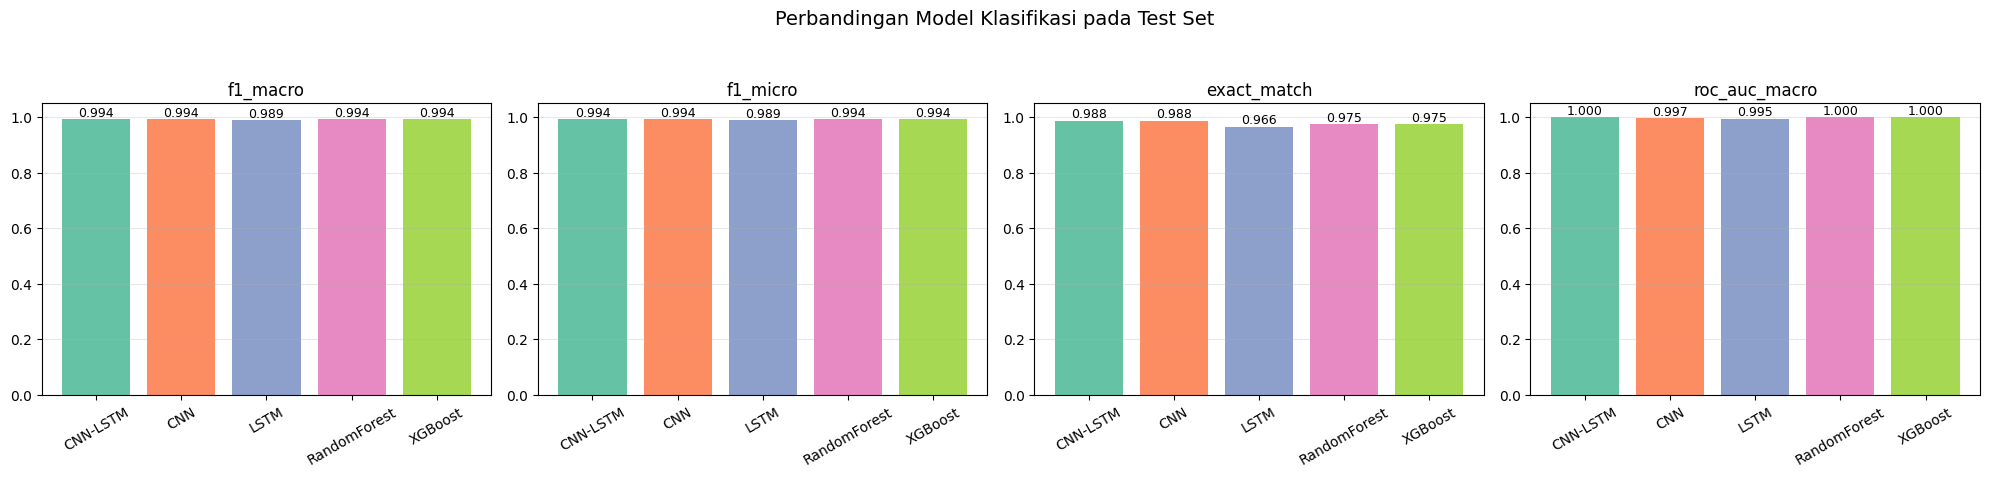

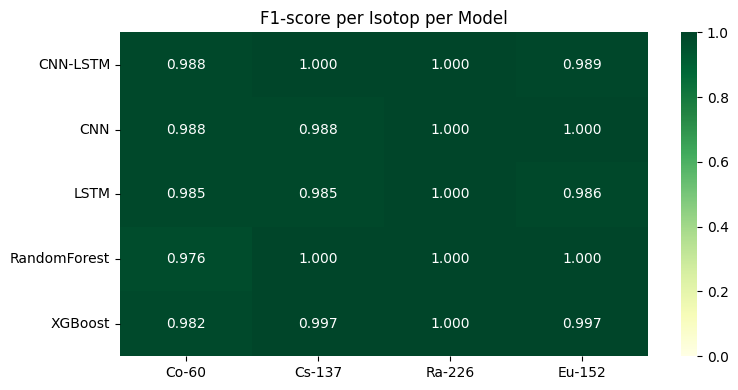

In [9]:
# Barplot perbandingan metrik utama
metrics_to_plot = ['f1_macro', 'f1_micro', 'exact_match', 'roc_auc_macro']
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(20, 4.5))
for ax, metric in zip(axes, metrics_to_plot):
    vals = [test_results[m][metric] for m in test_results]
    bars = ax.bar(test_results.keys(), vals, color=sns.color_palette('Set2', len(test_results)))
    ax.set_title(metric)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=30)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}', ha='center', fontsize=9)
    ax.grid(alpha=0.3, axis='y')
plt.suptitle('Perbandingan Model Klasifikasi pada Test Set', y=1.05, fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'comparison_klasifikasi.png'), dpi=120, bbox_inches='tight')
plt.show()

# Heatmap F1 per isotop
fig, ax = plt.subplots(figsize=(8, 4))
f1_iso = pd.DataFrame({m: [test_results[m][f'f1_{iso}'] for iso in ISOTOP]
                       for m in test_results}, index=ISOTOP).T
sns.heatmap(f1_iso, annot=True, fmt='.3f', cmap='YlGn', cbar=True, vmin=0, vmax=1, ax=ax)
ax.set_title('F1-score per Isotop per Model')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'f1_per_isotop.png'), dpi=120, bbox_inches='tight')
plt.show()

## 9. Ringkasan Hasil

Model terbaik dipilih berdasarkan **F1-macro** pada test set.

In [10]:
df = pd.DataFrame(test_results).T
ranking = df['f1_macro'].sort_values(ascending=False)
print('=== RANKING (by F1-macro test) ===')
for i, (m, v) in enumerate(ranking.items(), 1):
    marker = '⭐' if i == 1 else '  '
    print(f'  {marker} #{i} {m:15s}: F1-macro = {v:.4f}')

print(f'\nModel terbaik   : {ranking.index[0]}')
print(f'F1-macro test   : {ranking.iloc[0]:.4f}')
print(f'Best HP         : {best_params[ranking.index[0]]}')

# Save final report
with open(os.path.join(RESULTS_DIR, 'final_report_klasifikasi.txt'), 'w') as f:
    f.write('=== LAPORAN KLASIFIKASI MULTILABEL RADIONUKLIDA ===\n\n')
    f.write(f'Tanggal           : {time.strftime("%Y-%m-%d %H:%M")}\n')
    f.write(f'N_TRIALS per model: {N_TRIALS_PER_MODEL}\n\n')
    f.write('--- Test Set Metrics ---\n')
    f.write(df.round(4).to_string())
    f.write('\n\n--- Ranking (F1-macro) ---\n')
    for i, (m, v) in enumerate(ranking.items(), 1):
        f.write(f'  #{i} {m}: {v:.4f}\n')
    f.write(f'\nModel terbaik: {ranking.index[0]}\n')
    f.write(f'\nBest hyperparameters:\n')
    for m, hp in best_params.items():
        f.write(f'  {m}: {hp}\n')

print('\nFinal report disimpan.')

=== RANKING (by F1-macro test) ===
  ⭐ #1 CNN-LSTM       : F1-macro = 0.9941
     #2 CNN            : F1-macro = 0.9940
     #3 XGBoost        : F1-macro = 0.9940
     #4 RandomForest   : F1-macro = 0.9939
     #5 LSTM           : F1-macro = 0.9888

Model terbaik   : CNN-LSTM
F1-macro test   : 0.9941
Best HP         : {'n_filters': 16, 'kernel_size': 9, 'n_conv': 3, 'lstm_hidden': 64, 'bidirectional': True, 'dropout': 0.3077527684489511, 'lr': 0.007649452805711032, 'batch_size': 64, 'optimizer': 'adam'}

Final report disimpan.


## 10. Confusion Matrix, ROC, Precision-Recall, Classification Report

Visualisasi mendalam untuk setiap model & isotop, dihitung dari prediksi test set yang sudah disimpan.

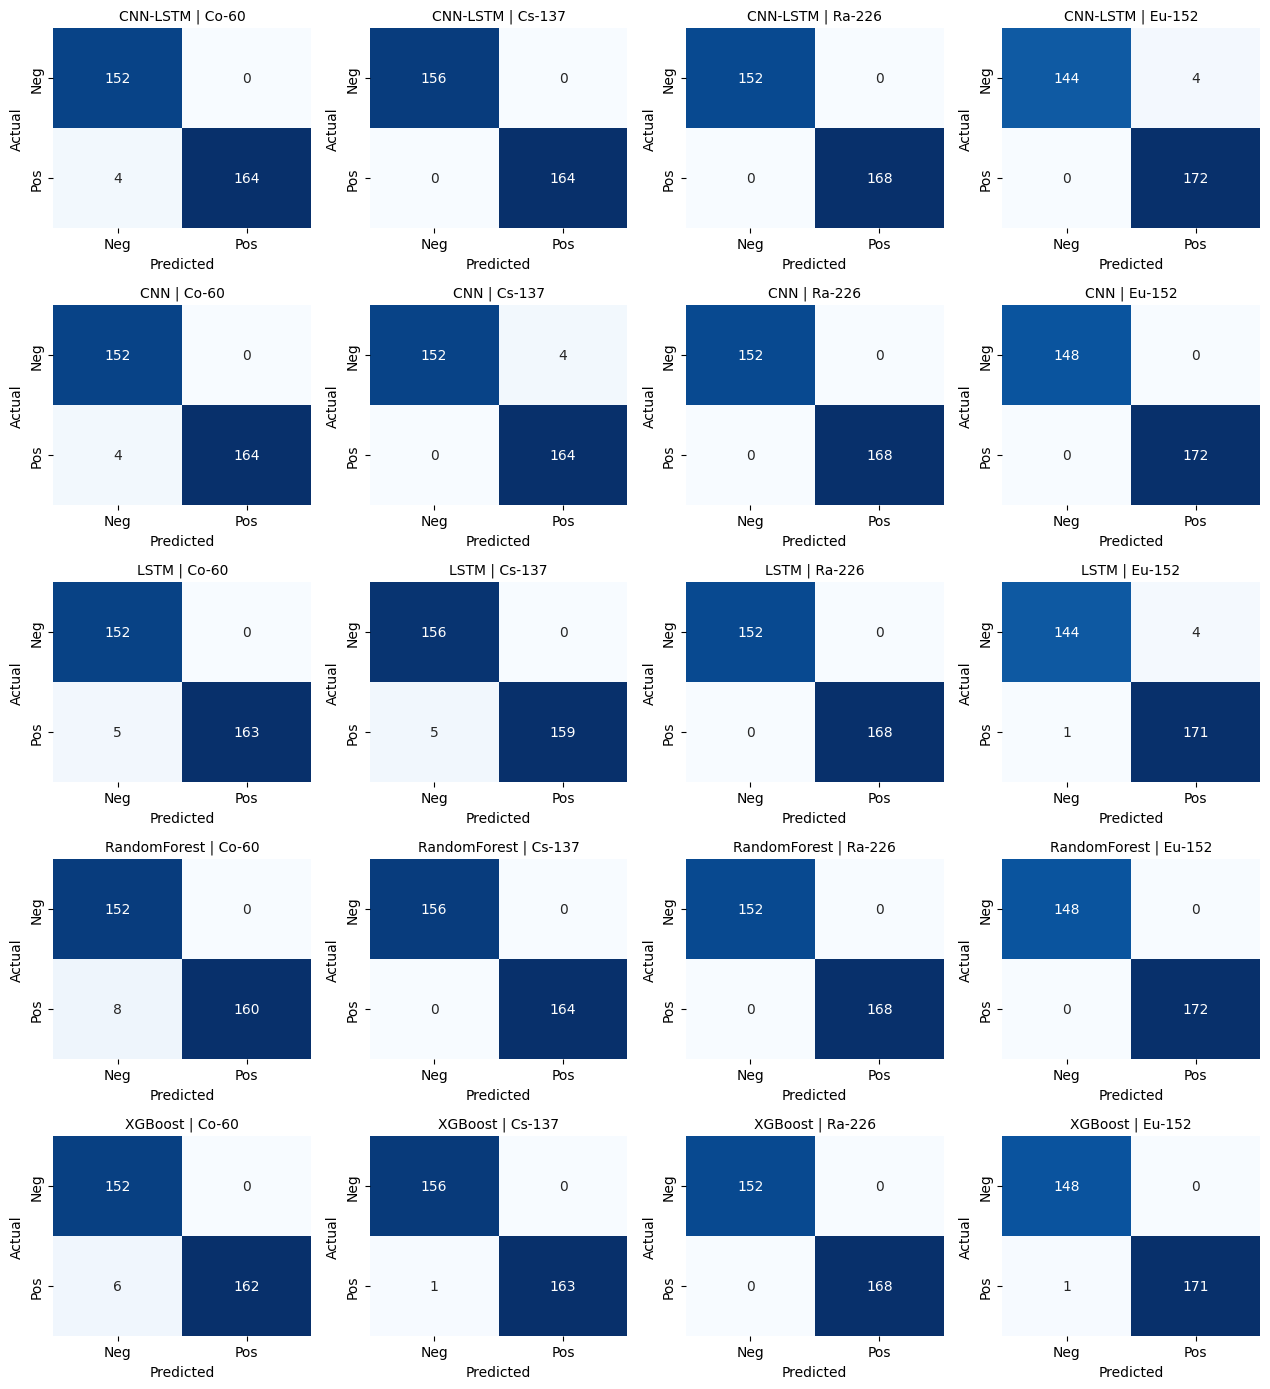

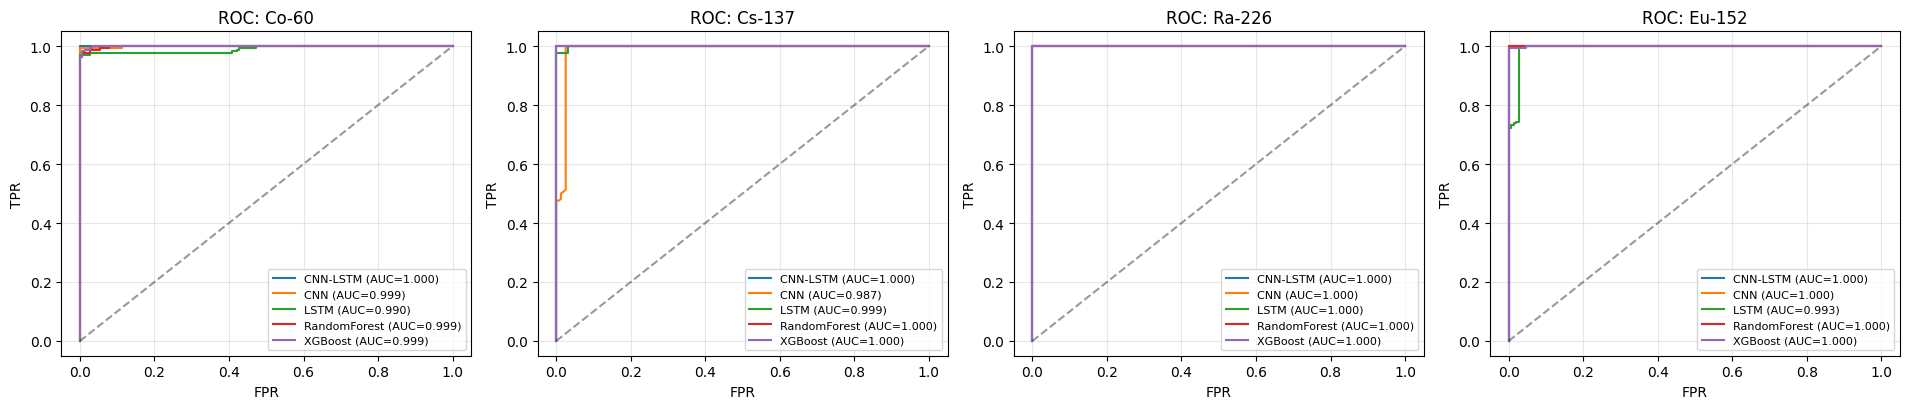

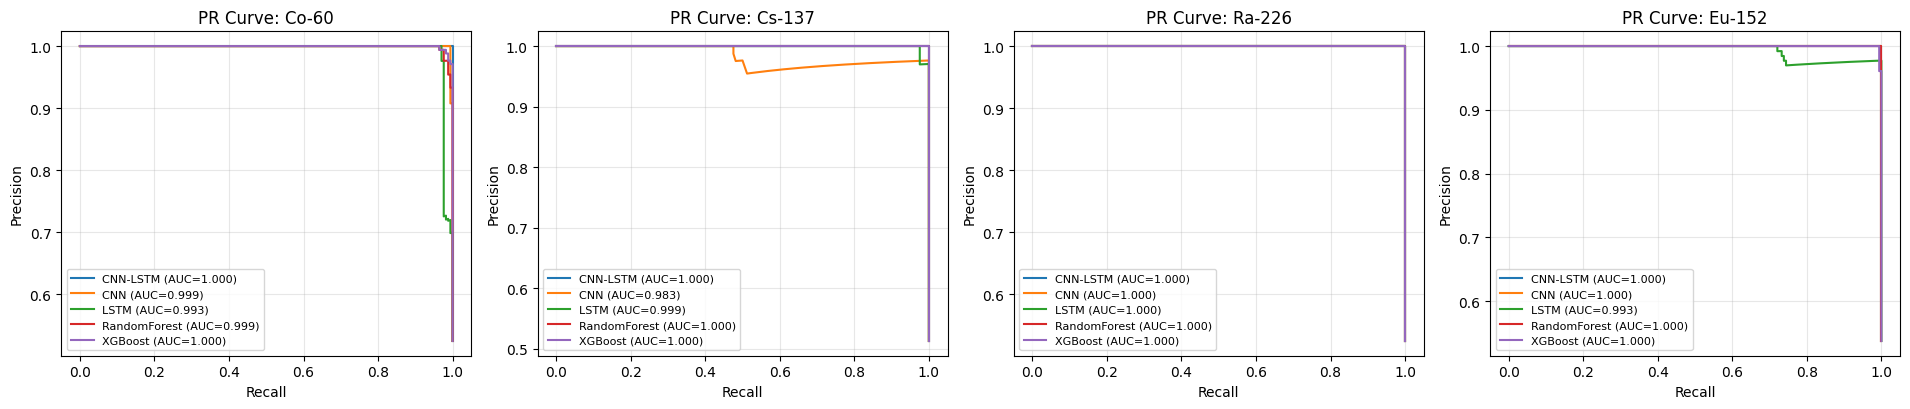


=== CNN-LSTM ===
              precision    recall  f1-score   support

       Co-60       1.00      0.98      0.99       168
      Cs-137       1.00      1.00      1.00       164
      Ra-226       1.00      1.00      1.00       168
      Eu-152       0.98      1.00      0.99       172

   micro avg       0.99      0.99      0.99       672
   macro avg       0.99      0.99      0.99       672
weighted avg       0.99      0.99      0.99       672
 samples avg       0.99      0.99      0.99       672


=== CNN ===
              precision    recall  f1-score   support

       Co-60       1.00      0.98      0.99       168
      Cs-137       0.98      1.00      0.99       164
      Ra-226       1.00      1.00      1.00       168
      Eu-152       1.00      1.00      1.00       172

   micro avg       0.99      0.99      0.99       672
   macro avg       0.99      0.99      0.99       672
weighted avg       0.99      0.99      0.99       672
 samples avg       0.99      0.99      0.99   

In [11]:
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve, auc, classification_report

preds_path = os.path.join(RESULTS_DIR, 'test_predictions_klasifikasi.npz')
preds_data = np.load(preds_path)
y_true = preds_data['y_test'].astype(int)
model_names = [k for k in preds_data.files if k != 'y_test']
ISOTOP_STR = [str(s) for s in ISOTOP]

# === A. Confusion matrix per isotop per model ===
fig, axes = plt.subplots(len(model_names), len(ISOTOP_STR),
                          figsize=(3.2*len(ISOTOP_STR), 2.8*len(model_names)))
for i, m in enumerate(model_names):
    pred = (preds_data[m] >= 0.5).astype(int)
    for j, iso in enumerate(ISOTOP_STR):
        ax = axes[i, j] if len(model_names) > 1 else axes[j]
        cm = confusion_matrix(y_true[:, j], pred[:, j], labels=[0, 1])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                     xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'], ax=ax)
        ax.set_title(f'{m} | {iso}', fontsize=10)
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix.png'), dpi=120, bbox_inches='tight')
plt.show()

# === B. ROC curve: per isotop, semua model overlaid ===
fig, axes = plt.subplots(1, len(ISOTOP_STR), figsize=(4.8*len(ISOTOP_STR), 4.2))
for j, (ax, iso) in enumerate(zip(axes, ISOTOP_STR)):
    for m in model_names:
        fpr, tpr, _ = roc_curve(y_true[:, j], preds_data[m][:, j])
        ax.plot(fpr, tpr, label=f'{m} (AUC={auc(fpr, tpr):.3f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_title(f'ROC: {iso}'); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(loc='lower right', fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_curves.png'), dpi=120, bbox_inches='tight')
plt.show()

# === C. Precision-Recall curve ===
fig, axes = plt.subplots(1, len(ISOTOP_STR), figsize=(4.8*len(ISOTOP_STR), 4.2))
for j, (ax, iso) in enumerate(zip(axes, ISOTOP_STR)):
    for m in model_names:
        prec, rec, _ = precision_recall_curve(y_true[:, j], preds_data[m][:, j])
        ax.plot(rec, prec, label=f'{m} (AUC={auc(rec, prec):.3f})')
    ax.set_title(f'PR Curve: {iso}'); ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.legend(loc='lower left', fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'pr_curves.png'), dpi=120, bbox_inches='tight')
plt.show()

# === D. Classification report (precision/recall/F1 per kelas) ===
report_lines = []
for m in model_names:
    pred = (preds_data[m] >= 0.5).astype(int)
    rep = classification_report(y_true, pred, target_names=ISOTOP_STR, zero_division=0)
    line = f'\n=== {m} ===\n{rep}'
    report_lines.append(line)
    print(line)

with open(os.path.join(RESULTS_DIR, 'classification_report.txt'), 'w') as f:
    f.write('\n'.join(report_lines))
print('Classification report disimpan.')

## 11. Training Loss Curves

Re-train tiga model DL singkat untuk merekam history loss train & validation per epoch. Diperlukan untuk menunjukkan konvergensi & ada/tidaknya overfitting di laporan.

Merekam training history untuk model DL...
  CNN-LSTM...
  CNN...
  LSTM...


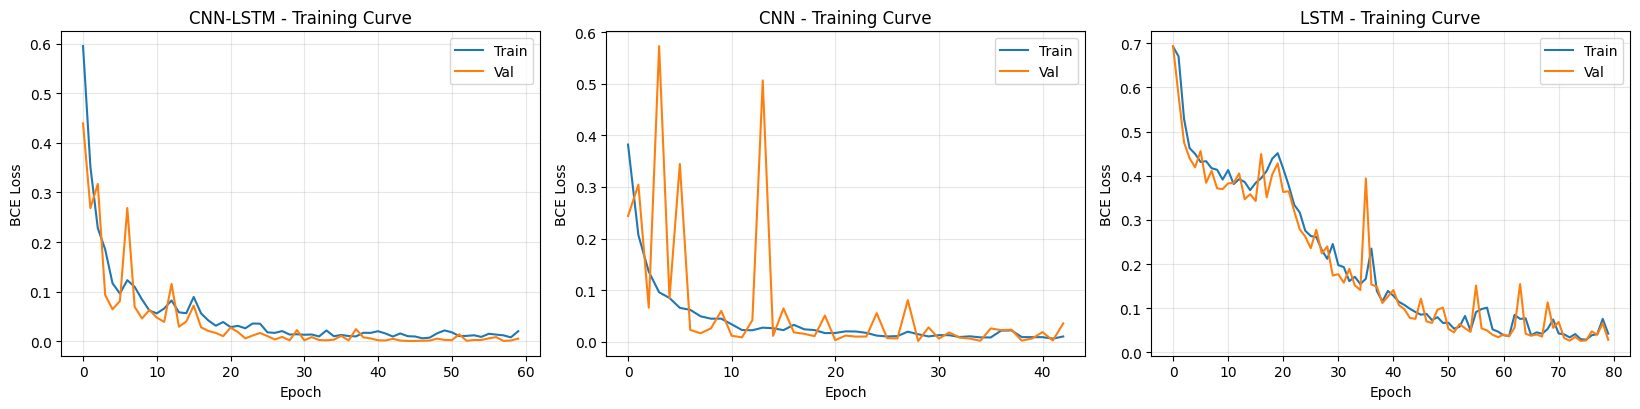

Training curves disimpan.


In [12]:
def train_with_history_cls(model_class, hp, X_tr, y_tr, X_va, y_va,
                            max_epochs=MAX_EPOCHS*2, patience=PATIENCE*2):
    arch_keys = [k for k in hp if k not in {'lr', 'batch_size', 'optimizer'}]
    arch_hp = {k: hp[k] for k in arch_keys}
    model = model_class(**arch_hp).to(DEVICE)

    Xt = torch.tensor(X_tr, dtype=torch.float32); yt = torch.tensor(y_tr, dtype=torch.float32)
    Xv = torch.tensor(X_va, dtype=torch.float32).to(DEVICE); yv = torch.tensor(y_va, dtype=torch.float32).to(DEVICE)
    loader = DataLoader(TensorDataset(Xt, yt), batch_size=hp['batch_size'], shuffle=True)

    if hp['optimizer'] == 'adam':
        opt = optim.Adam(model.parameters(), lr=hp['lr'])
    else:
        opt = optim.AdamW(model.parameters(), lr=hp['lr'], weight_decay=1e-4)

    loss_fn = nn.BCEWithLogitsLoss()
    tr_hist, va_hist = [], []
    best_val = float('inf'); wait = 0

    for epoch in range(max_epochs):
        model.train()
        ep_loss, n = 0.0, 0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward(); opt.step()
            ep_loss += loss.item() * len(xb); n += len(xb)
        model.eval()
        with torch.no_grad():
            vl = loss_fn(model(Xv), yv).item()
        tr_hist.append(ep_loss / n); va_hist.append(vl)
        if vl < best_val - 1e-5:
            best_val = vl; wait = 0
        else:
            wait += 1
            if wait >= patience: break
    return tr_hist, va_hist


# Load best_params kalau belum di memori
if 'best_params' not in globals():
    with open(os.path.join(RESULTS_DIR, 'best_hyperparams_klasifikasi.json')) as f:
        best_params = json.load(f)['best_params']

data = np.load(DATA_NPZ, allow_pickle=True)
X_full = np.concatenate([data['X_train'], data['X_val']], axis=0)
y_full = np.concatenate([data['y_cls_train'], data['y_cls_val']], axis=0)
rng = np.random.RandomState(SEED)
idx = rng.permutation(len(X_full))
sp = int(len(X_full) * 0.9)
tr_i, va_i = idx[:sp], idx[sp:]

histories = {}
print('Merekam training history untuk model DL...')
for name, cls in [('CNN-LSTM', CNN_LSTM), ('CNN', CNN_Only), ('LSTM', LSTM_Only)]:
    print(f'  {name}...')
    th, vh = train_with_history_cls(cls, best_params[name],
                                     X_full[tr_i], y_full[tr_i], X_full[va_i], y_full[va_i])
    histories[name] = {'train': th, 'val': vh}

fig, axes = plt.subplots(1, len(histories), figsize=(5.5*len(histories), 4.2))
for ax, (name, h) in zip(axes, histories.items()):
    ax.plot(h['train'], label='Train', color='tab:blue')
    ax.plot(h['val'],   label='Val',   color='tab:orange')
    ax.set_title(f'{name} - Training Curve')
    ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_curves.png'), dpi=120, bbox_inches='tight')
plt.show()

with open(os.path.join(RESULTS_DIR, 'training_history.json'), 'w') as f:
    json.dump(histories, f, indent=2)
print('Training curves disimpan.')

## 12. Analisis Tuning Optuna

Visualisasi hasil hyperparameter tuning: optimization history, parameter importance, parallel coordinate. Memvalidasi bahwa tuning sungguh-sungguh dilakukan dan konvergen.


--- CNN-LSTM (100 trials, best F1-macro=0.9963) ---


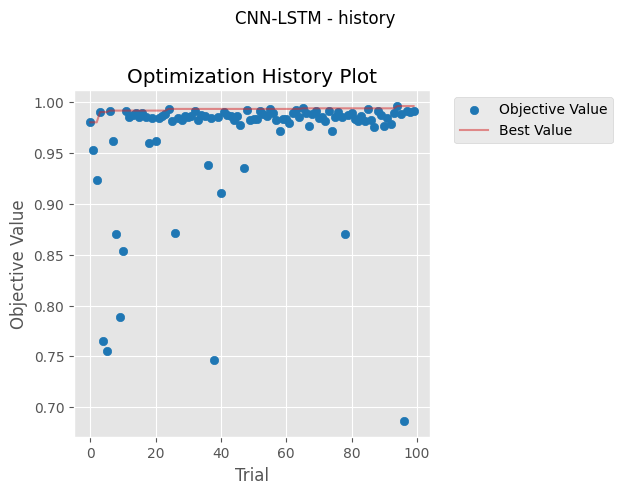

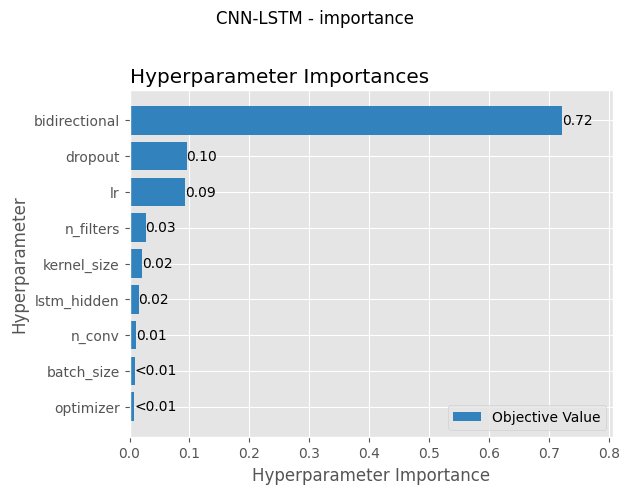

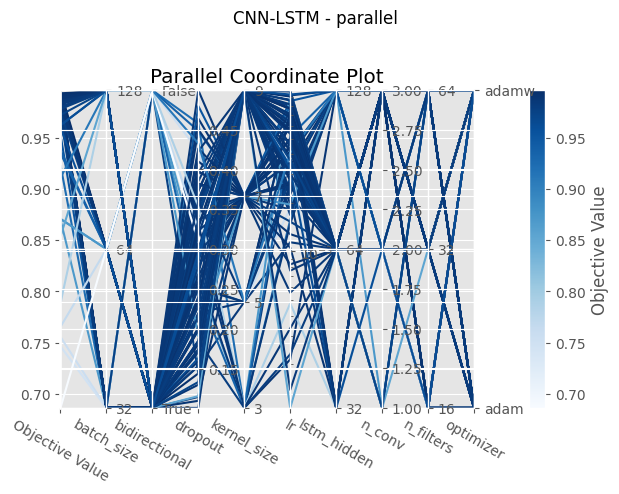


--- CNN (100 trials, best F1-macro=0.9970) ---


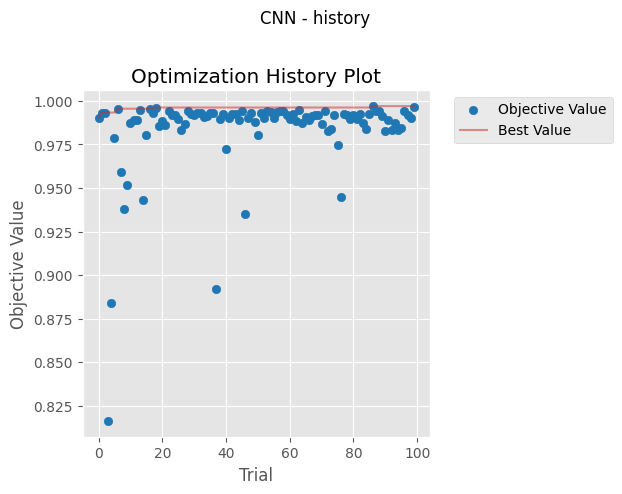

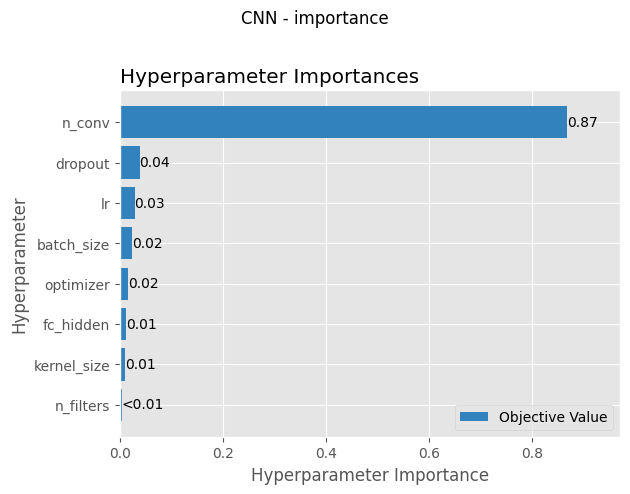

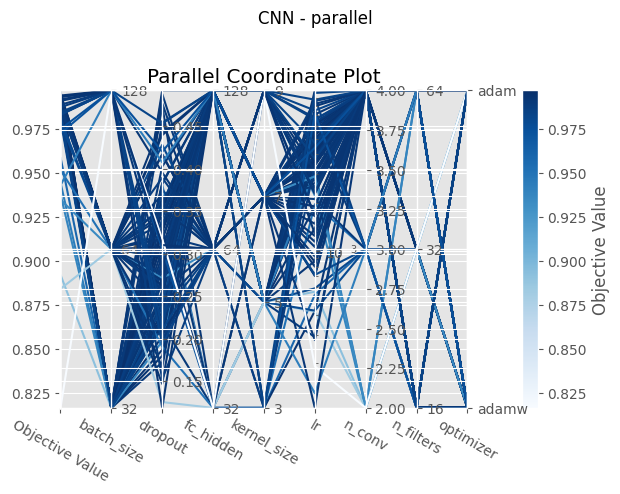


--- LSTM (100 trials, best F1-macro=0.9962) ---


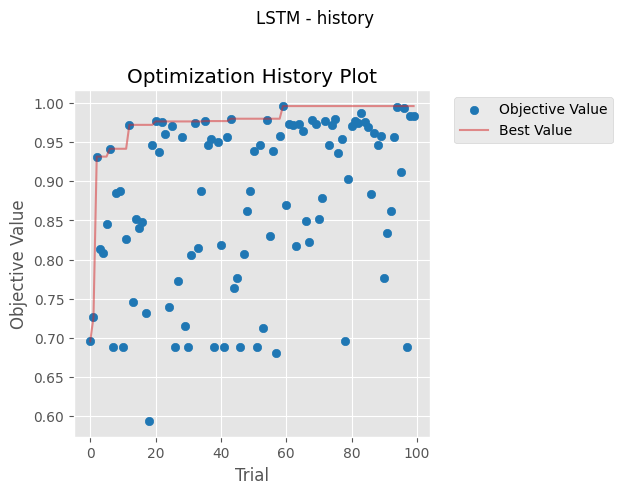

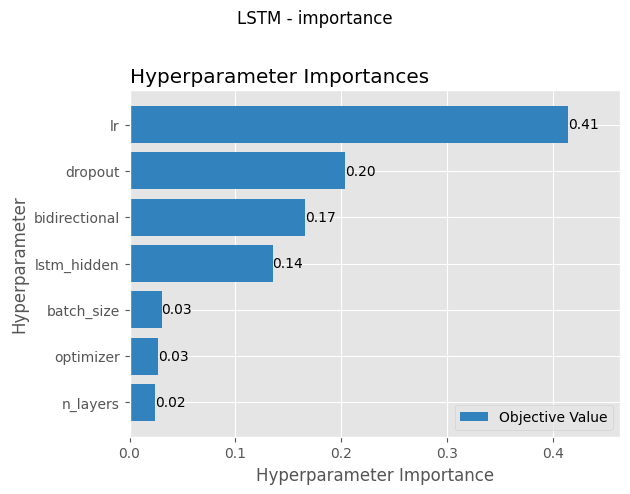

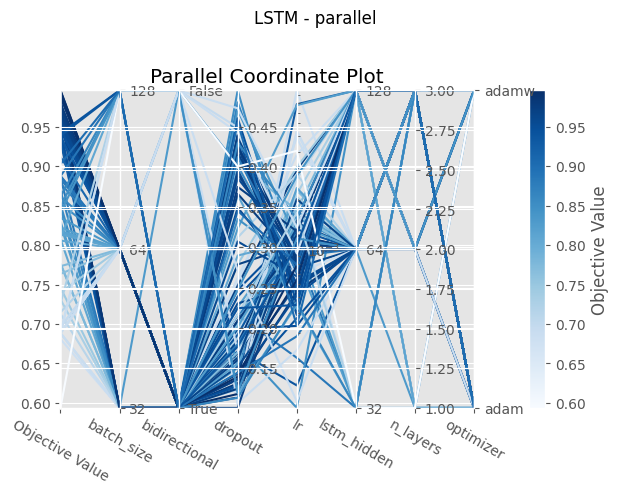


--- RandomForest (100 trials, best F1-macro=0.9970) ---


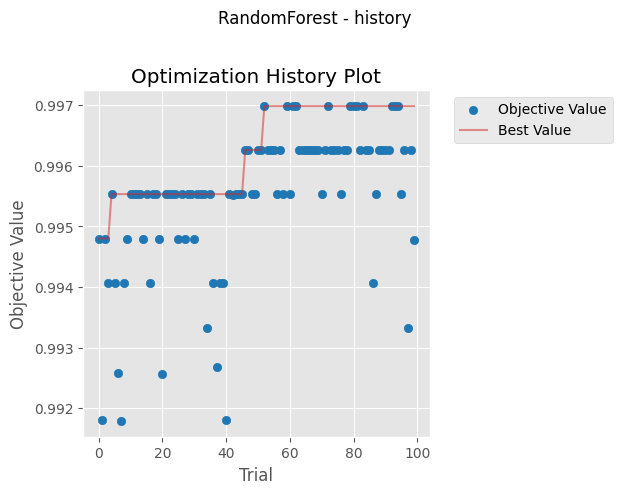

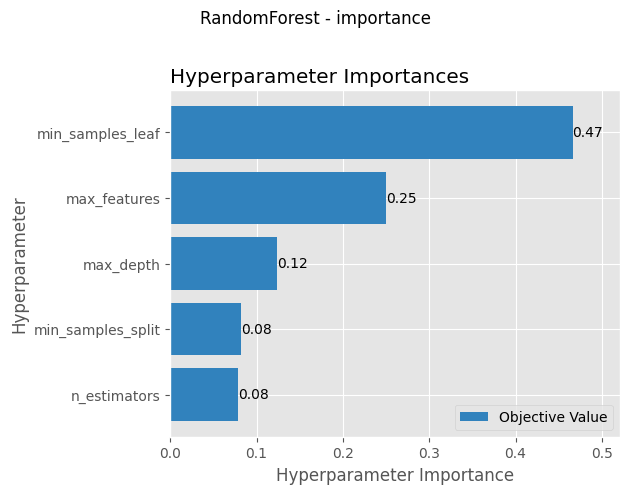

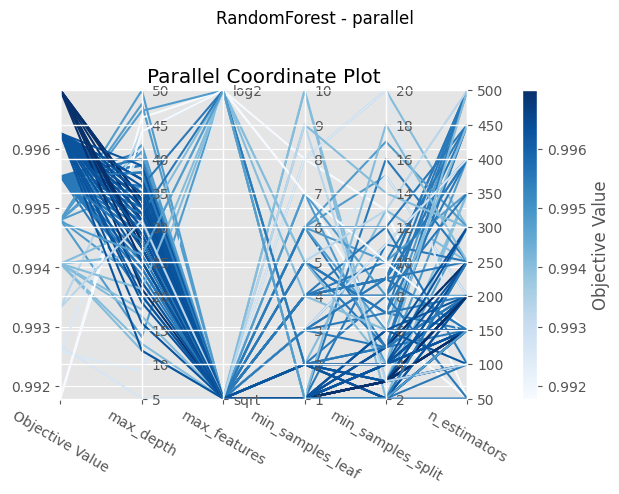


--- XGBoost (100 trials, best F1-macro=0.9993) ---


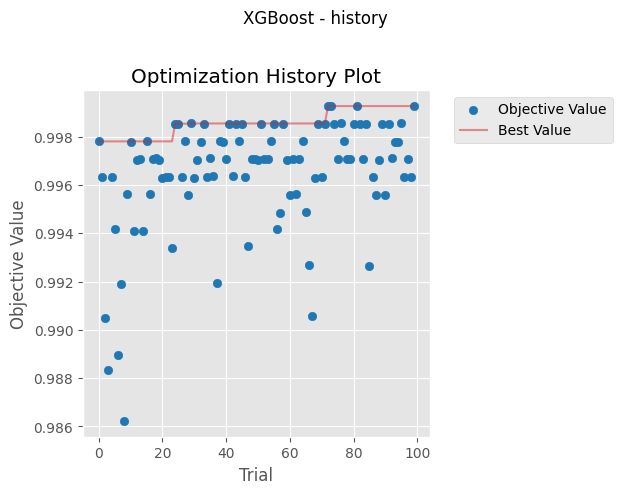

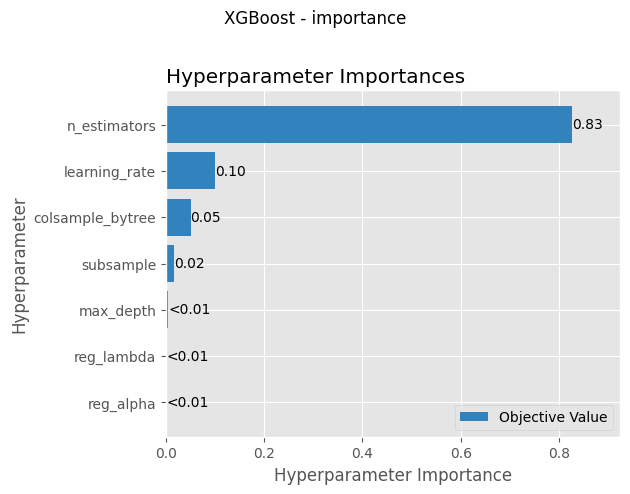

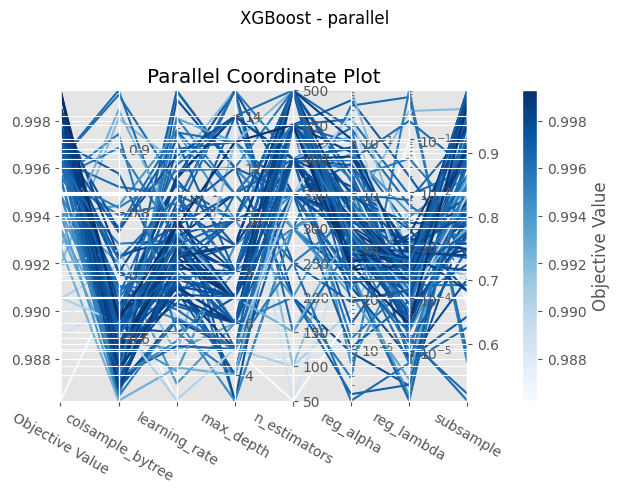


Optuna tuning analysis disimpan.


In [13]:
import optuna.visualization.matplotlib as ovm

for model_name in ['CNN-LSTM', 'CNN', 'LSTM', 'RandomForest', 'XGBoost']:
    try:
        study = optuna.load_study(study_name=f'cls_{model_name}', storage=STORAGE)
    except KeyError:
        print(f'  Study cls_{model_name} tidak ditemukan, skip.')
        continue
    print(f'\n--- {model_name} ({len(study.trials)} trials, best F1-macro={study.best_value:.4f}) ---')

    for plot_fn, suffix in [
        (ovm.plot_optimization_history, 'history'),
        (ovm.plot_param_importances,    'importance'),
        (ovm.plot_parallel_coordinate,  'parallel'),
    ]:
        try:
            ax = plot_fn(study)
            fig = ax.figure
            fig.suptitle(f'{model_name} - {suffix}', y=1.02)
            fig.tight_layout()
            fig.savefig(os.path.join(RESULTS_DIR, f'optuna_{model_name}_{suffix}.png'),
                         dpi=120, bbox_inches='tight')
            plt.show()
        except Exception as e:
            print(f'    skip {suffix}: {e}')
            plt.close('all')

print('\nOptuna tuning analysis disimpan.')

## 13. Reproducibility & Inference Benchmark

Tabel versi package, hardware, jumlah parameter & waktu inference per model. Wajib untuk bab Setup Penelitian dan klaim efisiensi model.

In [14]:
import platform, sklearn, pickle

env_info = {
    'Python'        : platform.python_version(),
    'OS'            : f'{platform.system()} {platform.release()}',
    'CPU cores'     : os.cpu_count(),
    'NumPy'         : np.__version__,
    'pandas'        : pd.__version__,
    'matplotlib'    : plt.matplotlib.__version__,
    'PyTorch'       : torch.__version__,
    'CUDA'          : torch.version.cuda if torch.cuda.is_available() else 'N/A',
    'GPU'           : torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A',
    'scikit-learn'  : sklearn.__version__,
    'XGBoost'       : xgb.__version__,
    'Optuna'        : optuna.__version__,
    'Random seed'   : SEED,
}
print('=== Environment ===')
for k, v in env_info.items():
    print(f'  {k:<14s}: {v}')
with open(os.path.join(RESULTS_DIR, 'environment.json'), 'w') as f:
    json.dump({k: str(v) for k, v in env_info.items()}, f, indent=2)

data = np.load(DATA_NPZ, allow_pickle=True)
X_test_arr = data['X_test']
n_test = len(X_test_arr)

if 'best_params' not in globals():
    with open(os.path.join(RESULTS_DIR, 'best_hyperparams_klasifikasi.json')) as f:
        best_params = json.load(f)['best_params']

bench = {}

# --- DL ---
for name, cls, ckpt in [('CNN-LSTM', CNN_LSTM, 'cnn_lstm_cls.pt'),
                         ('CNN', CNN_Only, 'cnn_cls.pt'),
                         ('LSTM', LSTM_Only, 'lstm_cls.pt')]:
    hp = best_params[name]
    arch_keys = [k for k in hp if k not in {'lr', 'batch_size', 'optimizer'}]
    arch_hp = {k: hp[k] for k in arch_keys}
    model = cls(**arch_hp).to(DEVICE)
    model.load_state_dict(torch.load(os.path.join(MODELS_DIR, ckpt), map_location=DEVICE))
    model.eval()
    n_params = sum(p.numel() for p in model.parameters())

    # Warmup
    xw = torch.randn(1, 1024).to(DEVICE)
    with torch.no_grad():
        for _ in range(10): _ = model(xw)

    # Single-sample latency
    xb = torch.tensor(X_test_arr, dtype=torch.float32).to(DEVICE)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    t0 = time.time()
    with torch.no_grad():
        for i in range(n_test):
            _ = model(xb[i:i+1])
    if torch.cuda.is_available(): torch.cuda.synchronize()
    dt_single = (time.time() - t0) / n_test * 1000

    # Batch inference
    if torch.cuda.is_available(): torch.cuda.synchronize()
    t0 = time.time()
    with torch.no_grad():
        _ = model(xb)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    dt_batch = (time.time() - t0) / n_test * 1000

    bench[name] = {
        '#Params/Complexity': n_params,
        'Latency single (ms)': round(dt_single, 4),
        'Latency batch (ms/sample)': round(dt_batch, 4),
    }

# --- Tree-based ---
for name, fname in [('RandomForest', 'rf_cls.pkl'), ('XGBoost', 'xgb_cls.pkl')]:
    with open(os.path.join(MODELS_DIR, fname), 'rb') as f:
        model = pickle.load(f)
    if name == 'RandomForest':
        n_params = sum(est.tree_.node_count
                        for clf in model.estimators_ for est in clf.estimators_)
    else:
        n_params = sum(int(clf.get_booster().num_boosted_rounds())
                        for clf in model.estimators_)
    # Single
    t0 = time.time()
    for i in range(n_test):
        _ = model.predict(X_test_arr[i:i+1])
    dt_single = (time.time() - t0) / n_test * 1000
    # Batch
    t0 = time.time()
    _ = model.predict(X_test_arr)
    dt_batch = (time.time() - t0) / n_test * 1000
    bench[name] = {
        '#Params/Complexity': n_params,
        'Latency single (ms)': round(dt_single, 4),
        'Latency batch (ms/sample)': round(dt_batch, 4),
    }

df_bench = pd.DataFrame(bench).T
print('\n=== Benchmark ===')
print(df_bench.to_string())
df_bench.to_csv(os.path.join(RESULTS_DIR, 'benchmark_klasifikasi.csv'))

# Catatan: untuk tree-based, #Params adalah proxy (RF=total node, XGB=total boosting rounds)
print('\nBenchmark & environment info disimpan.')

=== Environment ===
  Python        : 3.12.4
  OS            : Windows 11
  CPU cores     : 20
  NumPy         : 2.1.0
  pandas        : 2.2.2
  matplotlib    : 3.9.2
  PyTorch       : 2.6.0+cu124
  CUDA          : 12.4
  GPU           : NVIDIA GeForce RTX 3050 6GB Laptop GPU
  scikit-learn  : 1.6.1
  XGBoost       : 3.2.0
  Optuna        : 4.8.0
  Random seed   : 42

=== Benchmark ===
              #Params/Complexity  Latency single (ms)  Latency batch (ms/sample)
CNN-LSTM                 90596.0               1.2454                     0.0497
CNN                     114660.0               0.8462                     0.0217
LSTM                    233476.0               0.6394                     0.0764
RandomForest             46544.0             151.1084                     0.4582
XGBoost                   2000.0               3.0227                     0.0195

Benchmark & environment info disimpan.


## 14. Export Hyperparameter Tuning Trials ke Excel

Export semua trial Optuna dari 5 model ke file Excel berstyle:
- **Sheet `Summary`** - best per model, di-rank dari yang terbaik.
- **Sheet `All_Trials_Ranking`** - SEMUA trial dari semua model, diurutkan dari F1-macro terbaik (tertinggi) ke terburuk.
- **Satu sheet per model** - SEMUA trial dengan kolom lengkap (Run, Trial, hyperparameter, Val F1-macro, Duration, Rank).

Styling: header berwarna, *color scale* pada kolom metric, *freeze panes*, baris terbaik di-highlight hijau, auto-width.

In [15]:
import optuna
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.formatting.rule import ColorScaleRule
from openpyxl.utils import get_column_letter

# ====== Konfigurasi ======
STUDY_PREFIX = "cls_"
METRIC_NAME  = "F1-macro"
DIRECTION    = "maximize"        # 'maximize' atau 'minimize'
MODEL_NAMES  = ['CNN-LSTM', 'CNN', 'LSTM', 'RandomForest', 'XGBoost']
RUN_SIZE     = 10                      # 1 Run = 10 Trial (seperti tabel referensi)
OUT_XLSX     = os.path.join(RESULTS_DIR, "tuning_trials_klasifikasi.xlsx")
METRIC_COL   = f"Val {METRIC_NAME}"
ASC          = (DIRECTION == "minimize")

# ====== Load Optuna studies ======
studies = {}
for name in MODEL_NAMES:
    try:
        studies[name] = optuna.load_study(study_name=f"{STUDY_PREFIX}{name}", storage=STORAGE)
        print(f"  Loaded {STUDY_PREFIX}{name}: {len(studies[name].trials)} trials")
    except KeyError:
        print(f"  WARNING: study {STUDY_PREFIX}{name} tidak ditemukan, skip.")

# ====== Convert ke DataFrame per model ======
trial_dfs = {}
for model_name, study in studies.items():
    rows = []
    for t in sorted(study.trials, key=lambda x: x.number):
        if t.value is None or t.state.name != "COMPLETE":
            continue
        params = {k: (str(v) if isinstance(v, (list, tuple)) else v) for k, v in t.params.items()}
        duration = None
        if t.datetime_complete and t.datetime_start:
            duration = round((t.datetime_complete - t.datetime_start).total_seconds(), 2)
        rows.append({
            "Run":    t.number // RUN_SIZE + 1,
            "Trial":  t.number + 1,
            **params,
            METRIC_COL:     round(float(t.value), 6),
            "Duration (s)": duration,
        })
    df = pd.DataFrame(rows)
    df["Rank in Model"] = df[METRIC_COL].rank(ascending=ASC, method="min").astype(int)
    trial_dfs[model_name] = df

# ====== Gabungan semua trial untuk ranking sheet ======
all_rows = []
for model_name, df in trial_dfs.items():
    for _, r in df.iterrows():
        all_rows.append({"Model": model_name, **r.to_dict()})
df_all = pd.DataFrame(all_rows)
df_all["Global Rank"]   = df_all[METRIC_COL].rank(ascending=ASC, method="min").astype(int)
df_all_sorted = df_all.sort_values(METRIC_COL, ascending=ASC).reset_index(drop=True)

# ====== Summary: best per model ======
summary_rows = []
for model_name, df in trial_dfs.items():
    best_idx = df[METRIC_COL].idxmin() if ASC else df[METRIC_COL].idxmax()
    best = df.loc[best_idx]
    summary_rows.append({
        "Model":             model_name,
        "N Trials":          len(df),
        f"Best {METRIC_COL}": best[METRIC_COL],
        "Best Trial #":       int(best["Trial"]),
        "Best Run":           int(best["Run"]),
        f"Mean {METRIC_COL}": round(df[METRIC_COL].mean(), 6),
        f"Std {METRIC_COL}":  round(df[METRIC_COL].std(),  6),
    })
df_summary = pd.DataFrame(summary_rows).sort_values(
    f"Best {METRIC_COL}", ascending=ASC
).reset_index(drop=True)
df_summary.insert(0, "Rank", range(1, len(df_summary) + 1))


# ====== Helper styling Excel ======
def _style_sheet(ws, df, metric_col, direction, freeze="A2"):
    header_font = Font(bold=True, color="FFFFFF", size=11, name="Calibri")
    header_fill = PatternFill("solid", fgColor="1F4E78")
    best_fill   = PatternFill("solid", fgColor="C6EFCE")
    thin_side   = Side(style="thin", color="D9D9D9")
    border      = Border(left=thin_side, right=thin_side, top=thin_side, bottom=thin_side)
    align       = Alignment(horizontal="center", vertical="center")

    # Header
    for c, col in enumerate(df.columns, 1):
        cell = ws.cell(1, c, str(col))
        cell.font = header_font
        cell.fill = header_fill
        cell.alignment = align
        cell.border = border
    ws.row_dimensions[1].height = 26

    # Data
    for r in range(len(df)):
        for c, col in enumerate(df.columns, 1):
            v = df.iloc[r, c - 1]
            if hasattr(v, "item"):
                v = v.item()
            if isinstance(v, float) and pd.isna(v):
                v = None
            cell = ws.cell(r + 2, c, v)
            cell.border = border
            cell.alignment = align
            if isinstance(v, float):
                cell.number_format = "0.000000" if (abs(v) < 0.01 and v != 0) else "0.0000"

    # Highlight best row (by metric)
    if metric_col in df.columns and len(df) > 0:
        idx = df[metric_col].idxmin() if direction == "minimize" else df[metric_col].idxmax()
        best_excel_row = df.index.get_loc(idx) + 2
        for c in range(1, len(df.columns) + 1):
            cell = ws.cell(best_excel_row, c)
            cell.fill = best_fill
            cell.font = Font(bold=True)

    # Color-scale conditional formatting pada metric column
    if metric_col in df.columns and len(df) > 1:
        c = list(df.columns).index(metric_col) + 1
        col_letter = get_column_letter(c)
        last = len(df) + 1
        if direction == "maximize":
            rule = ColorScaleRule(
                start_type="min", start_color="F8696B",
                mid_type="percentile", mid_value=50, mid_color="FFEB84",
                end_type="max", end_color="63BE7B"
            )
        else:
            rule = ColorScaleRule(
                start_type="min", start_color="63BE7B",
                mid_type="percentile", mid_value=50, mid_color="FFEB84",
                end_type="max", end_color="F8696B"
            )
        ws.conditional_formatting.add(f"{col_letter}2:{col_letter}{last}", rule)

    # Freeze + auto-width
    ws.freeze_panes = freeze
    for c, col in enumerate(df.columns, 1):
        lengths = [len(str(col))]
        for r in range(min(len(df), 200)):
            try:
                lengths.append(len(str(df.iloc[r, c - 1])))
            except Exception:
                pass
        ws.column_dimensions[get_column_letter(c)].width = min(max(max(lengths) + 2, 10), 28)


# ====== Tulis Excel ======
wb = Workbook()
wb.remove(wb.active)

# Sheet 1: Summary (best per model)
ws = wb.create_sheet("Summary")
_style_sheet(ws, df_summary, f"Best {METRIC_COL}", DIRECTION)

# Sheet 2: All_Trials_Ranking
ws = wb.create_sheet("All_Trials_Ranking")
front = ["Global Rank", "Model", "Run", "Trial", METRIC_COL, "Duration (s)", "Rank in Model"]
front = [c for c in front if c in df_all_sorted.columns]
other = [c for c in df_all_sorted.columns if c not in front]
_style_sheet(ws, df_all_sorted[front + other], METRIC_COL, DIRECTION)

# Sheet per model
for model_name, df in trial_dfs.items():
    ws = wb.create_sheet(model_name)
    front = ["Run", "Trial", "Rank in Model", METRIC_COL, "Duration (s)"]
    front = [c for c in front if c in df.columns]
    other = [c for c in df.columns if c not in front]
    _style_sheet(ws, df[front + other], METRIC_COL, DIRECTION)

wb.save(OUT_XLSX)
print(f"\nExcel disimpan: {OUT_XLSX}")
print(f"  Sheets: Summary, All_Trials_Ranking, {', '.join(trial_dfs.keys())}")

print("\n=== Summary: Best per Model ===")
print(df_summary.to_string(index=False))

print(f"\n=== Top 10 Trials Overall (direction={DIRECTION}) ===")
preview = ["Global Rank", "Model", "Run", "Trial", METRIC_COL]
preview = [c for c in preview if c in df_all_sorted.columns]
print(df_all_sorted.head(10)[preview].to_string(index=False))


  Loaded cls_CNN-LSTM: 100 trials
  Loaded cls_CNN: 100 trials
  Loaded cls_LSTM: 100 trials
  Loaded cls_RandomForest: 100 trials
  Loaded cls_XGBoost: 100 trials

Excel disimpan: C:\Users\wahyu\OneDrive\TA & Skripsi\TA&Skripsi\Olah data (2)\results_klasifikasi\tuning_trials_klasifikasi.xlsx
  Sheets: Summary, All_Trials_Ranking, CNN-LSTM, CNN, LSTM, RandomForest, XGBoost

=== Summary: Best per Model ===
 Rank        Model  N Trials  Best Val F1-macro  Best Trial #  Best Run  Mean Val F1-macro  Std Val F1-macro
    1      XGBoost       100           0.999275            73         8           0.996498          0.002395
    2          CNN       100           0.997023            87         9           0.983636          0.024874
    3 RandomForest       100           0.996988            53         6           0.995499          0.001192
    4     CNN-LSTM       100           0.996281            95        10           0.966100          0.057302
    5         LSTM       100           0.99623

## 15. Training Curves Detail: Loss + Accuracy + F1 per Epoch

Re-train model dengan tracking loss + accuracy + F1-macro per epoch (DL), log-loss + accuracy per boosting round (XGBoost), dan OOB error vs jumlah pohon (RandomForest).

Merekam history (loss, accuracy, F1-macro) untuk model DL klasifikasi...
  CNN-LSTM ...
  CNN ...
  LSTM ...


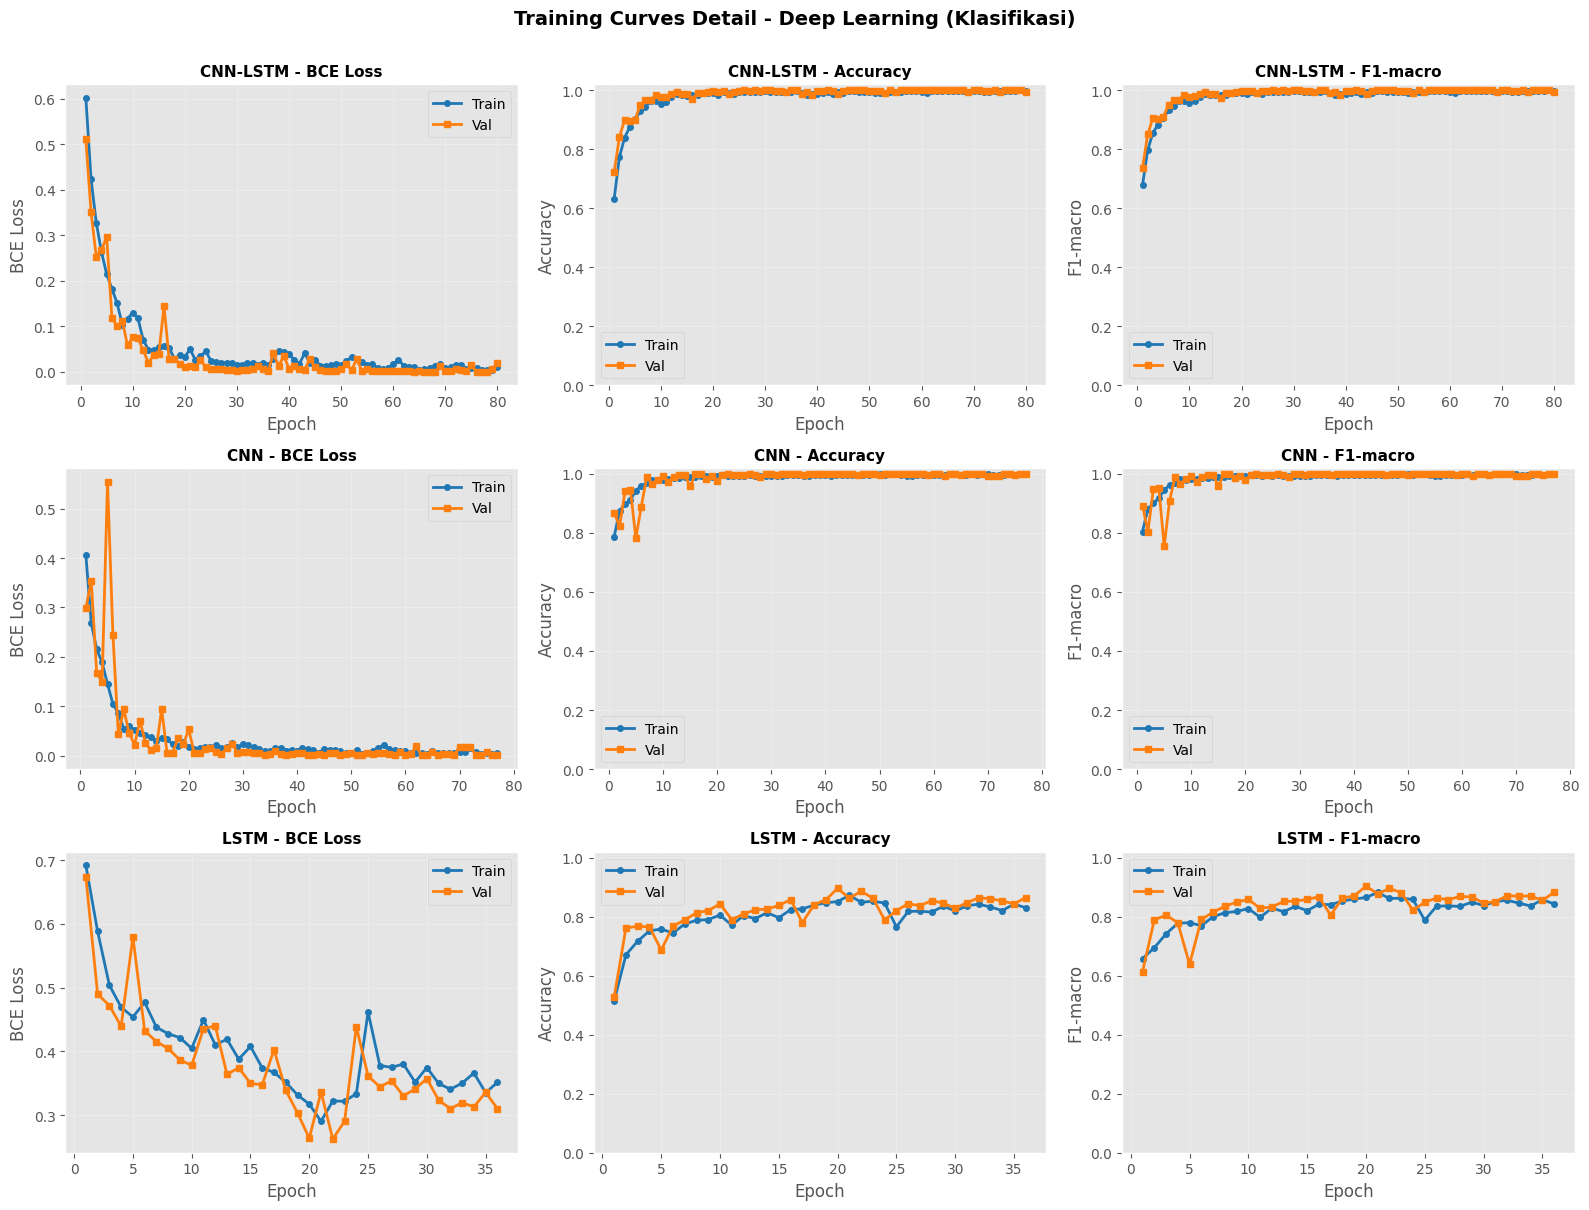


Merekam history XGBoost per boosting round (per isotop)...


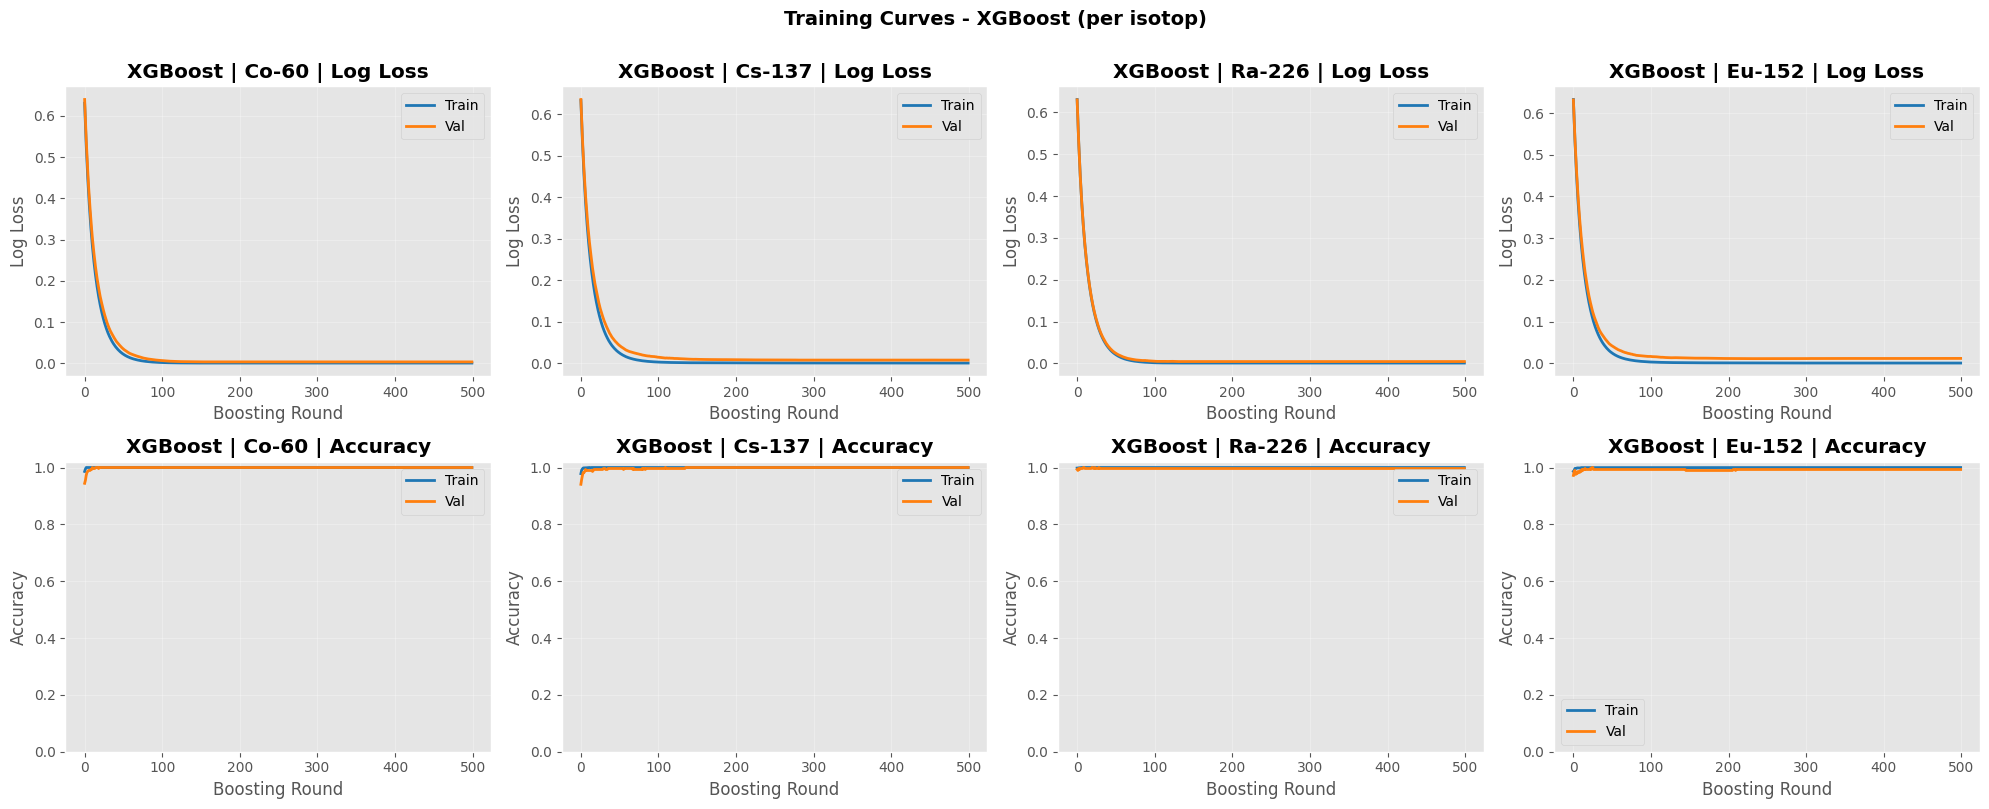


Merekam OOB error RandomForest vs jumlah pohon (per isotop)...


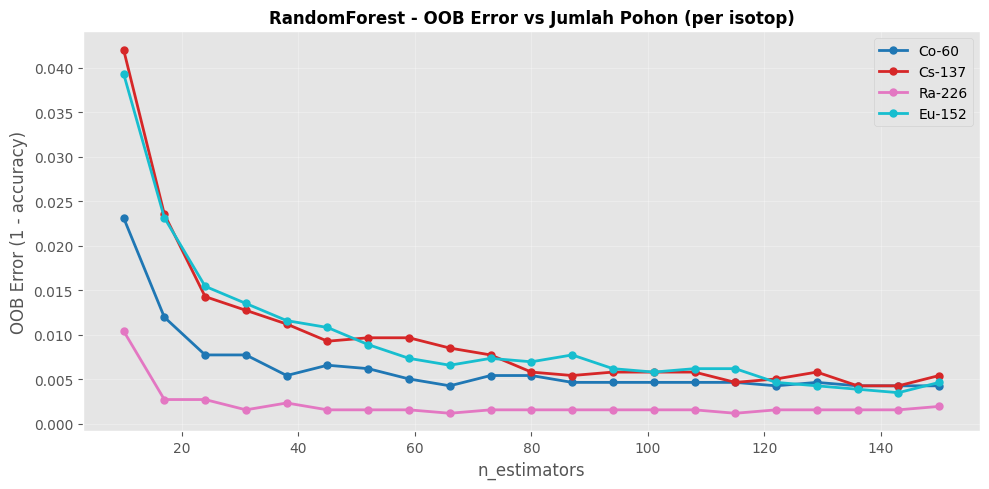


Semua training curves disimpan ke C:\Users\wahyu\OneDrive\TA & Skripsi\TA&Skripsi\Olah data (2)\results_klasifikasi


In [16]:
# Training curves detail untuk model klasifikasi.
# NOTE: cell ini re-train model DL utk merekam loss+accuracy+F1 per epoch.
#       Total waktu ~10-15 menit di GPU RTX 3050.

if 'best_params' not in globals():
    with open(os.path.join(RESULTS_DIR, 'best_hyperparams_klasifikasi.json')) as f:
        best_params = json.load(f)['best_params']

data = np.load(DATA_NPZ, allow_pickle=True)
X_full = np.concatenate([data['X_train'], data['X_val']], axis=0)
y_full = np.concatenate([data['y_cls_train'], data['y_cls_val']], axis=0).astype(np.float32)
rng = np.random.RandomState(SEED)
idx = rng.permutation(len(X_full))
sp = int(len(X_full) * 0.9)
tr_i, va_i = idx[:sp], idx[sp:]


def train_full_history_cls(model_class, hp, max_epochs=MAX_EPOCHS*2, patience=PATIENCE*2):
    """Rekam train/val loss + accuracy + F1-macro per epoch."""
    arch_keys = [k for k in hp if k not in {'lr', 'batch_size', 'optimizer'}]
    arch_hp = {k: hp[k] for k in arch_keys}
    model = model_class(**arch_hp).to(DEVICE)

    Xtr = torch.tensor(X_full[tr_i], dtype=torch.float32)
    ytr = torch.tensor(y_full[tr_i], dtype=torch.float32)
    Xva = torch.tensor(X_full[va_i], dtype=torch.float32).to(DEVICE)
    yva = torch.tensor(y_full[va_i], dtype=torch.float32).to(DEVICE)
    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=hp['batch_size'], shuffle=True)

    opt = (optim.Adam(model.parameters(), lr=hp['lr']) if hp['optimizer'] == 'adam'
           else optim.AdamW(model.parameters(), lr=hp['lr'], weight_decay=1e-4))
    loss_fn = nn.BCEWithLogitsLoss()

    H = {k: [] for k in ['train_loss','val_loss','train_acc','val_acc','train_f1','val_f1']}
    best_val, wait = float('inf'), 0
    for epoch in range(max_epochs):
        model.train()
        ep_loss, n = 0.0, 0
        tr_logits_all, tr_y_all = [], []
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward(); opt.step()
            ep_loss += loss.item() * len(xb); n += len(xb)
            tr_logits_all.append(logits.detach()); tr_y_all.append(yb.detach())

        with torch.no_grad():
            tr_l = torch.cat(tr_logits_all); tr_y_t = torch.cat(tr_y_all)
            tr_pred = (torch.sigmoid(tr_l) >= 0.5).cpu().numpy().astype(int)
            tr_yn   = tr_y_t.cpu().numpy().astype(int)
            H['train_loss'].append(ep_loss / n)
            H['train_acc'].append(float((tr_pred == tr_yn).mean()))
            H['train_f1'].append(float(f1_score(tr_yn, tr_pred, average='macro', zero_division=0)))

            model.eval()
            v_l = model(Xva); vl_val = loss_fn(v_l, yva).item()
            v_pred = (torch.sigmoid(v_l) >= 0.5).cpu().numpy().astype(int)
            v_yn   = yva.cpu().numpy().astype(int)
            H['val_loss'].append(vl_val)
            H['val_acc'].append(float((v_pred == v_yn).mean()))
            H['val_f1'].append(float(f1_score(v_yn, v_pred, average='macro', zero_division=0)))

        if vl_val < best_val - 1e-5:
            best_val, wait = vl_val, 0
        else:
            wait += 1
            if wait >= patience:
                break
    return H


dl_histories = {}
print('Merekam history (loss, accuracy, F1-macro) untuk model DL klasifikasi...')
for name, cls in [('CNN-LSTM', CNN_LSTM), ('CNN', CNN_Only), ('LSTM', LSTM_Only)]:
    print(f'  {name} ...')
    dl_histories[name] = train_full_history_cls(cls, best_params[name])

# Plot DL: rows=model, cols=[Loss, Accuracy, F1]
fig, axes = plt.subplots(len(dl_histories), 3, figsize=(16, 4.0 * len(dl_histories)))
for i, (name, H) in enumerate(dl_histories.items()):
    epochs = range(1, len(H['train_loss']) + 1)
    for j, (key, ylabel, ylim) in enumerate([
        ('loss', 'BCE Loss', None),
        ('acc',  'Accuracy', (0, 1.02)),
        ('f1',   'F1-macro', (0, 1.02)),
    ]):
        ax = axes[i, j] if len(dl_histories) > 1 else axes[j]
        ax.plot(epochs, H[f'train_{key}'], 'o-', label='Train', color='#1f77b4', ms=4, lw=2)
        ax.plot(epochs, H[f'val_{key}'],   's-', label='Val',   color='#ff7f0e', ms=4, lw=2)
        ax.set_title(f'{name} - {ylabel}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        if ylim: ax.set_ylim(*ylim)
        ax.legend(loc='best'); ax.grid(alpha=0.3)
plt.suptitle('Training Curves Detail - Deep Learning (Klasifikasi)',
             y=1.005, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_curves_detailed.png'),
            dpi=120, bbox_inches='tight')
plt.show()

with open(os.path.join(RESULTS_DIR, 'training_history_detailed.json'), 'w') as f:
    json.dump(dl_histories, f, indent=2)


# ====== XGBoost: log-loss + accuracy per boosting round ======
print('\nMerekam history XGBoost per boosting round (per isotop)...')
xgb_hp = dict(best_params['XGBoost'])
xgb_histories = {}
for i, iso in enumerate([str(s) for s in ISOTOP]):
    base = xgb.XGBClassifier(**xgb_hp, random_state=SEED, n_jobs=-1,
                              eval_metric=['logloss', 'error'], verbosity=0)
    base.fit(X_full[tr_i], y_full[tr_i].astype(int)[:, i],
             eval_set=[(X_full[tr_i], y_full[tr_i].astype(int)[:, i]),
                       (X_full[va_i], y_full[va_i].astype(int)[:, i])],
             verbose=False)
    xgb_histories[iso] = base.evals_result()

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for i, (iso, res) in enumerate(xgb_histories.items()):
    ax = axes[0, i]
    ax.plot(res['validation_0']['logloss'], label='Train', color='#1f77b4', lw=2)
    ax.plot(res['validation_1']['logloss'], label='Val',   color='#ff7f0e', lw=2)
    ax.set_title(f'XGBoost | {iso} | Log Loss', fontweight='bold')
    ax.set_xlabel('Boosting Round'); ax.set_ylabel('Log Loss')
    ax.legend(); ax.grid(alpha=0.3)

    ax = axes[1, i]
    tr_acc = [1 - e for e in res['validation_0']['error']]
    va_acc = [1 - e for e in res['validation_1']['error']]
    ax.plot(tr_acc, label='Train', color='#1f77b4', lw=2)
    ax.plot(va_acc, label='Val',   color='#ff7f0e', lw=2)
    ax.set_title(f'XGBoost | {iso} | Accuracy', fontweight='bold')
    ax.set_xlabel('Boosting Round'); ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1.02); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Training Curves - XGBoost (per isotop)',
             y=1.005, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_curves_xgboost.png'),
            dpi=120, bbox_inches='tight')
plt.show()


# ====== RandomForest: OOB error vs jumlah pohon (per isotop) ======
print('\nMerekam OOB error RandomForest vs jumlah pohon (per isotop)...')
from sklearn.ensemble import RandomForestClassifier as _RFC
rf_hp = dict(best_params['RandomForest'])
max_n = rf_hp.pop('n_estimators')
n_estimators_list = list(range(10, max_n + 1, max(1, max_n // 20)))

oob_errors = {}
for i, iso in enumerate([str(s) for s in ISOTOP]):
    rf = _RFC(**rf_hp, n_estimators=n_estimators_list[0], oob_score=True,
              warm_start=True, random_state=SEED, n_jobs=-1, bootstrap=True)
    errs = []
    for n_tree in n_estimators_list:
        rf.set_params(n_estimators=n_tree)
        rf.fit(X_full[tr_i], y_full[tr_i].astype(int)[:, i])
        errs.append(1 - rf.oob_score_)
    oob_errors[iso] = errs

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(oob_errors)))
for (iso, errs), c in zip(oob_errors.items(), colors):
    ax.plot(n_estimators_list, errs, 'o-', label=iso, lw=2, ms=5, color=c)
ax.set_title('RandomForest - OOB Error vs Jumlah Pohon (per isotop)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('n_estimators'); ax.set_ylabel('OOB Error (1 - accuracy)')
ax.legend(loc='best'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_curves_rf.png'),
            dpi=120, bbox_inches='tight')
plt.show()

print('\nSemua training curves disimpan ke', RESULTS_DIR)
